In [1]:
#basics
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#itertools
from itertools import product

# plotly and dash
import dash
from dash import dcc, html
import plotly.offline as pyo
import plotly.graph_objs as go
from dash.dependencies import Input, Output
from dash.exceptions import PreventUpdate

In [2]:
file_path = (
    "../../0_Volve_dataset/5_Production_data/Volve_production_data.xlsx"
)


production_df=pd.read_excel(file_path)
production_df

,DATEPRD,WELL_BORE_CODE,NPD_WELL_BORE_CODE,NPD_WELL_BORE_NAME,NPD_FIELD_CODE,NPD_FIELD_NAME,NPD_FACILITY_CODE,NPD_FACILITY_NAME,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,...,AVG_CHOKE_UOM,AVG_WHP_P,AVG_WHT_P,DP_CHOKE_SIZE,BORE_OIL_VOL,BORE_GAS_VOL,BORE_WAT_VOL,BORE_WI_VOL,FLOW_KIND,WELL_TYPE
0,2014-04-07,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,0.00000,...,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,WI
1,2014-04-08,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP
2,2014-04-09,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP
3,2014-04-10,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP
4,2014-04-11,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,310.37614,...,%,33.09788,10.47992,33.07195,0.0,0.0,0.0,NaN,production,OP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15629,2016-09-14,NO 15/9-F-5 AH,5769,15/9-F-5,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,%,0.07776,0.22879,0.01862,0.0,0.0,0.0,NaN,production,OP
15630,2016-09-15,NO 15/9-F-5 AH,5769,15/9-F-5,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,%,0.08545,0.22914,0.00631,0.0,0.0,0.0,NaN,production,OP
15631,2016-09-16,NO 15/9-F-5 AH,5769,15/9-F-5,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,%,0.08544,0.22896,0.01181,0.0,0.0,0.0,NaN,production,OP
15632,2016-09-17,NO 15/9-F-5 AH,5769,15/9-F-5,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,%,0.07497,0.22846,0.02576,0.0,0.0,0.0,NaN,production,OP


In [3]:
production_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15634 entries, 0 to 15633
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   DATEPRD                   15634 non-null  datetime64[us]
 1   WELL_BORE_CODE            15634 non-null  str           
 2   NPD_WELL_BORE_CODE        15634 non-null  int64         
 3   NPD_WELL_BORE_NAME        15634 non-null  str           
 4   NPD_FIELD_CODE            15634 non-null  int64         
 5   NPD_FIELD_NAME            15634 non-null  str           
 6   NPD_FACILITY_CODE         15634 non-null  int64         
 7   NPD_FACILITY_NAME         15634 non-null  str           
 8   ON_STREAM_HRS             15349 non-null  float64       
 9   AVG_DOWNHOLE_PRESSURE     8980 non-null   float64       
 10  AVG_DOWNHOLE_TEMPERATURE  8980 non-null   float64       
 11  AVG_DP_TUBING             8980 non-null   float64       
 12  AVG_ANNULUS_PRESS         789

In [4]:
# find the unique number of wells names
unique_wellnames=production_df["NPD_WELL_BORE_NAME"].unique()
unique_wellnames

<StringArray>
[ '15/9-F-1 C',   '15/9-F-11',   '15/9-F-12',   '15/9-F-14', '15/9-F-15 D',
    '15/9-F-4',    '15/9-F-5']
Length: 7, dtype: str

In [5]:
# find column name list
column_names=production_df.columns
column_names

Index(['DATEPRD', 'WELL_BORE_CODE', 'NPD_WELL_BORE_CODE', 'NPD_WELL_BORE_NAME',
       'NPD_FIELD_CODE', 'NPD_FIELD_NAME', 'NPD_FACILITY_CODE',
       'NPD_FACILITY_NAME', 'ON_STREAM_HRS', 'AVG_DOWNHOLE_PRESSURE',
       'AVG_DOWNHOLE_TEMPERATURE', 'AVG_DP_TUBING', 'AVG_ANNULUS_PRESS',
       'AVG_CHOKE_SIZE_P', 'AVG_CHOKE_UOM', 'AVG_WHP_P', 'AVG_WHT_P',
       'DP_CHOKE_SIZE', 'BORE_OIL_VOL', 'BORE_GAS_VOL', 'BORE_WAT_VOL',
       'BORE_WI_VOL', 'FLOW_KIND', 'WELL_TYPE'],
      dtype='str')

## QC for missing data


In [6]:
# total numbers of rows
total_rows=len(production_df)
total_rows

15634

In [7]:
# missing row per column 
print(production_df.isna().sum())

DATEPRD                        0
WELL_BORE_CODE                 0
NPD_WELL_BORE_CODE             0
NPD_WELL_BORE_NAME             0
NPD_FIELD_CODE                 0
NPD_FIELD_NAME                 0
NPD_FACILITY_CODE              0
NPD_FACILITY_NAME              0
ON_STREAM_HRS                285
AVG_DOWNHOLE_PRESSURE       6654
AVG_DOWNHOLE_TEMPERATURE    6654
AVG_DP_TUBING               6654
AVG_ANNULUS_PRESS           7744
AVG_CHOKE_SIZE_P            6715
AVG_CHOKE_UOM               6473
AVG_WHP_P                   6479
AVG_WHT_P                   6488
DP_CHOKE_SIZE                294
BORE_OIL_VOL                6473
BORE_GAS_VOL                6473
BORE_WAT_VOL                6473
BORE_WI_VOL                 9928
FLOW_KIND                      0
WELL_TYPE                      0
dtype: int64


In [8]:
# missing data per column 
"looks like a lot of data is missing for" 
"AVG_DOWNHOLE_PRESSURE"
"AVG_DOWNHOLE_TEMPERATURE"
"AVG_DP_TUBING"
"AVG_DP_TUBING"
"AVG_ANNULUS_PRESS"
"AVG_WHT_P"
production_df.isna().mean() 

DATEPRD                     0.000000
WELL_BORE_CODE              0.000000
NPD_WELL_BORE_CODE          0.000000
NPD_WELL_BORE_NAME          0.000000
NPD_FIELD_CODE              0.000000
NPD_FIELD_NAME              0.000000
NPD_FACILITY_CODE           0.000000
NPD_FACILITY_NAME           0.000000
ON_STREAM_HRS               0.018229
AVG_DOWNHOLE_PRESSURE       0.425611
AVG_DOWNHOLE_TEMPERATURE    0.425611
AVG_DP_TUBING               0.425611
AVG_ANNULUS_PRESS           0.495331
AVG_CHOKE_SIZE_P            0.429513
AVG_CHOKE_UOM               0.414034
AVG_WHP_P                   0.414417
AVG_WHT_P                   0.414993
DP_CHOKE_SIZE               0.018805
BORE_OIL_VOL                0.414034
BORE_GAS_VOL                0.414034
BORE_WAT_VOL                0.414034
BORE_WI_VOL                 0.635026
FLOW_KIND                   0.000000
WELL_TYPE                   0.000000
dtype: float64

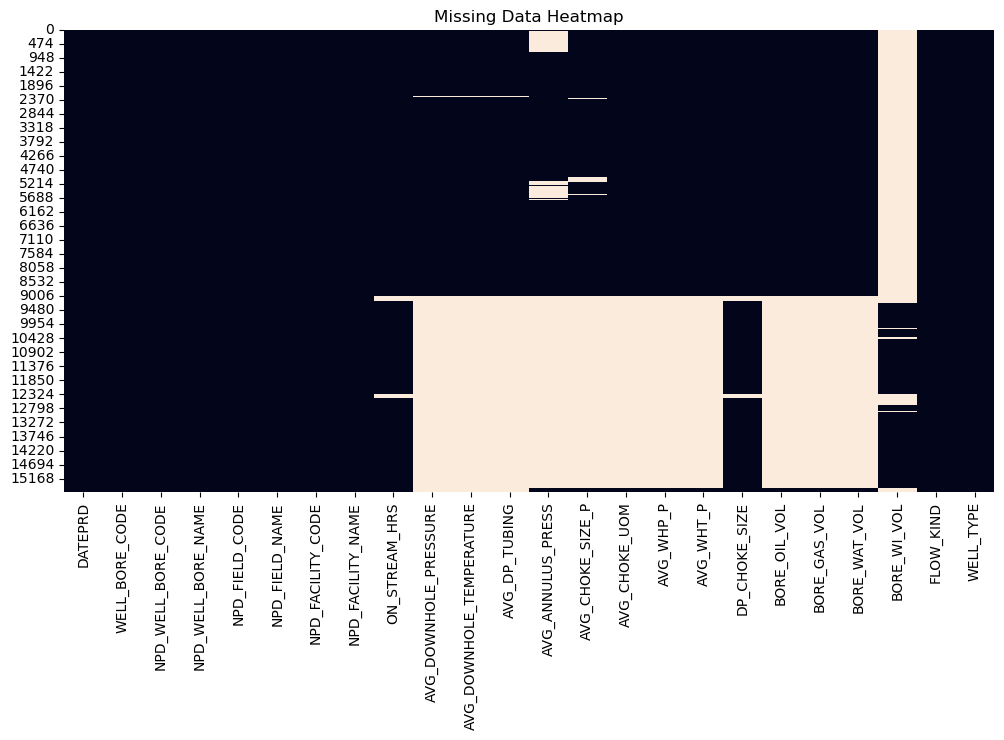

In [9]:
# see the amount of missing data you have using a heatmap
plt.figure(figsize=(12,6))
sns.heatmap(production_df.isna(), cbar=False)
plt.title("Missing Data Heatmap")
plt.show()

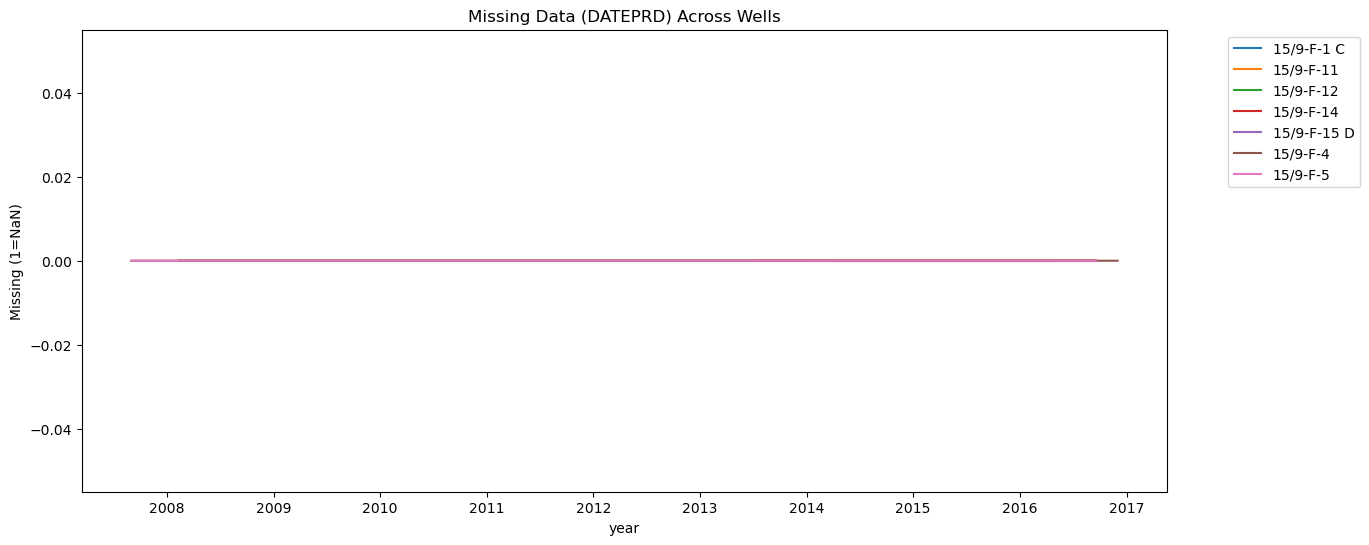

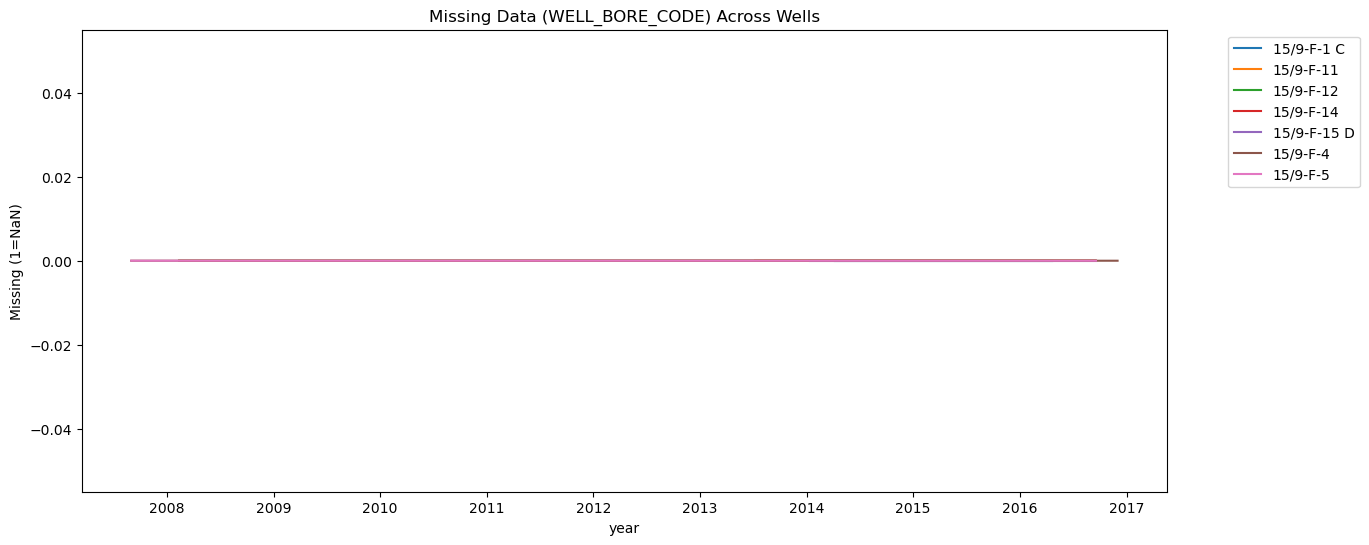

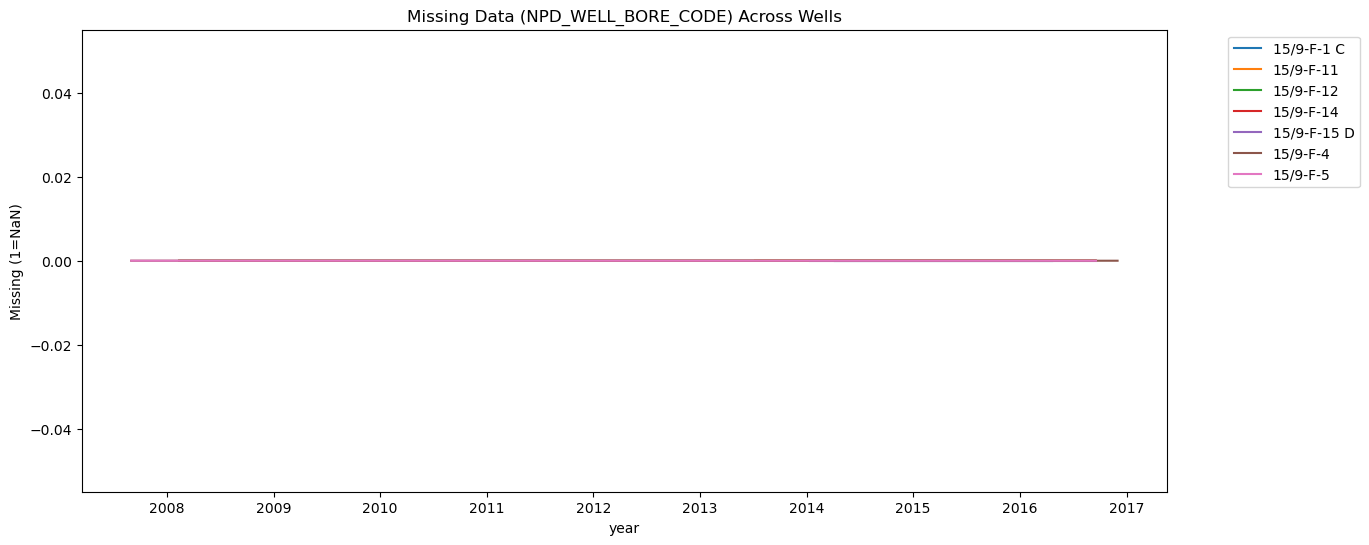

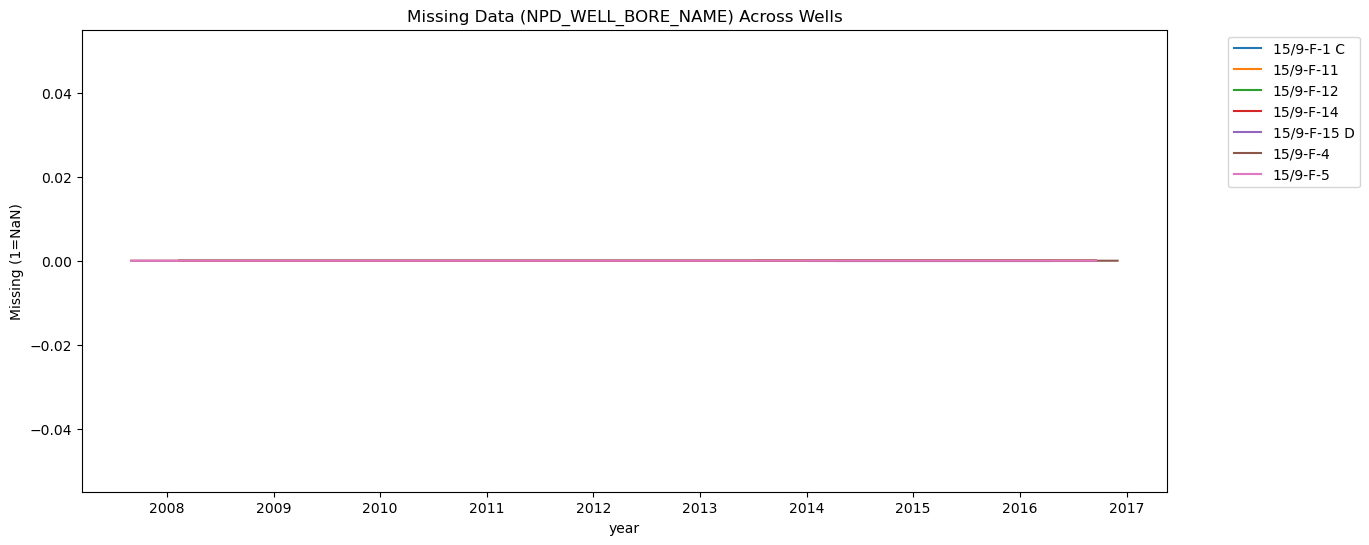

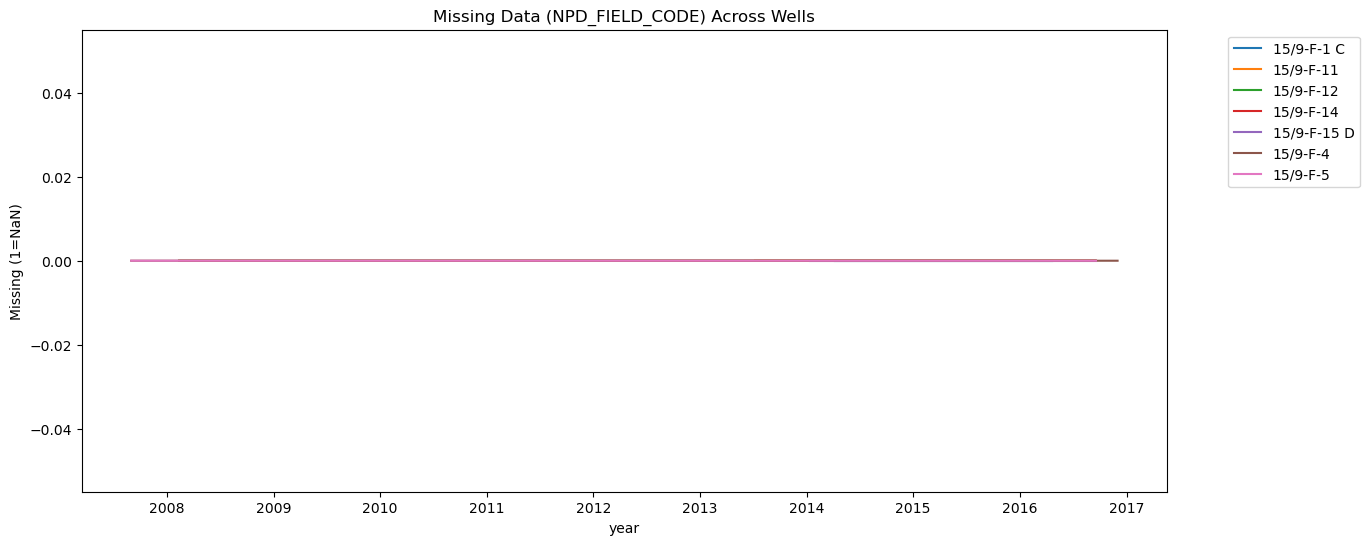

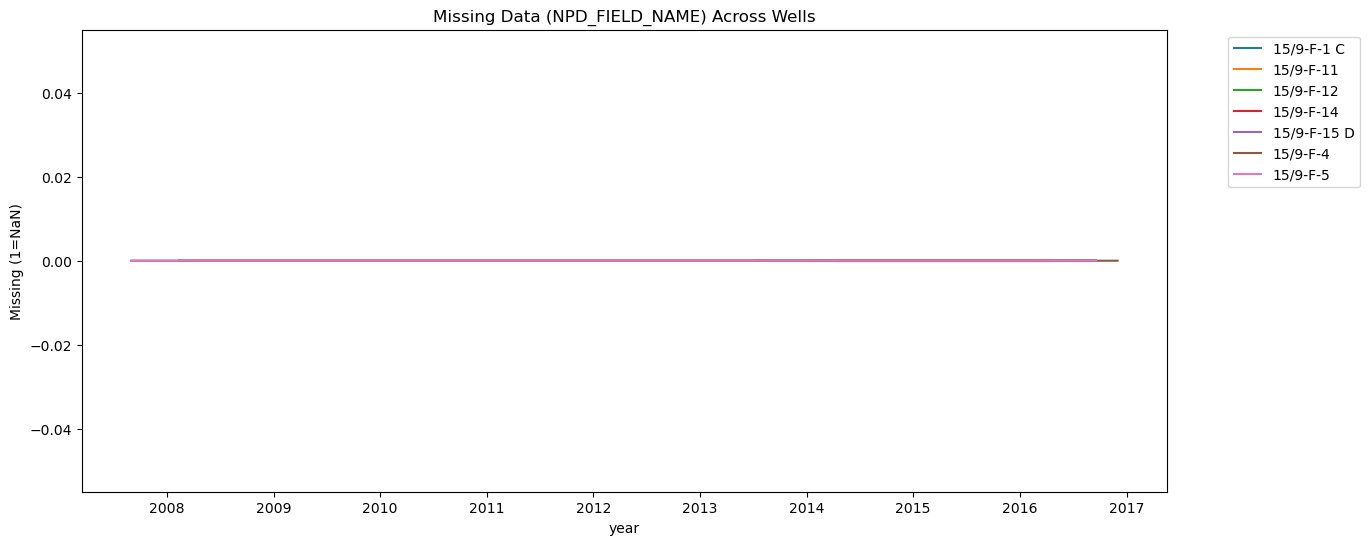

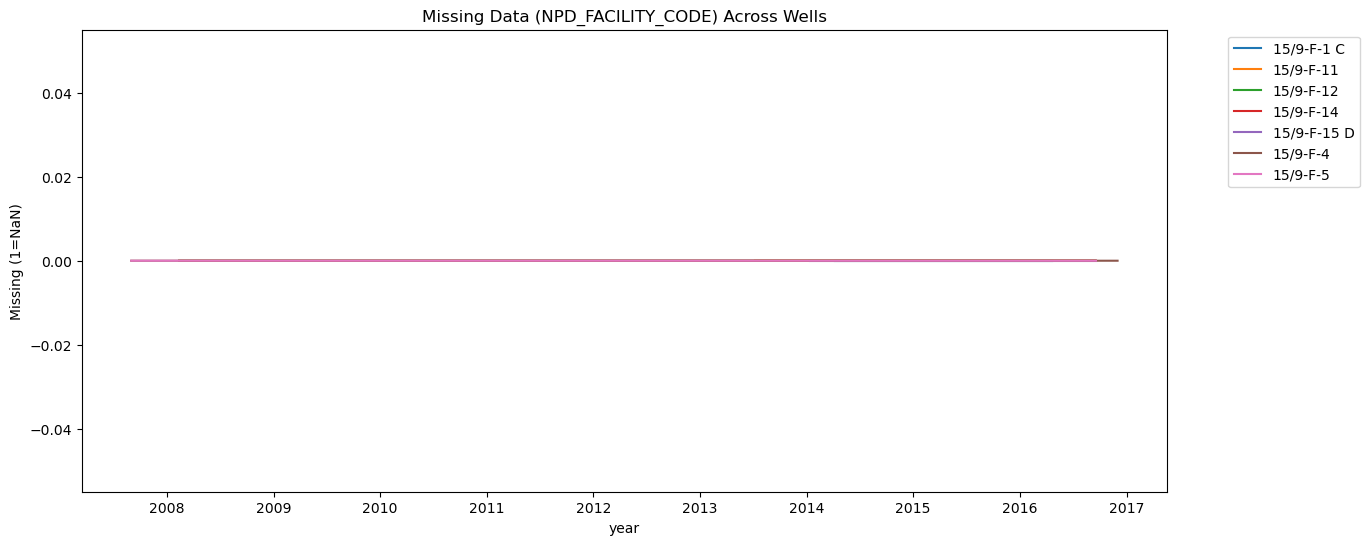

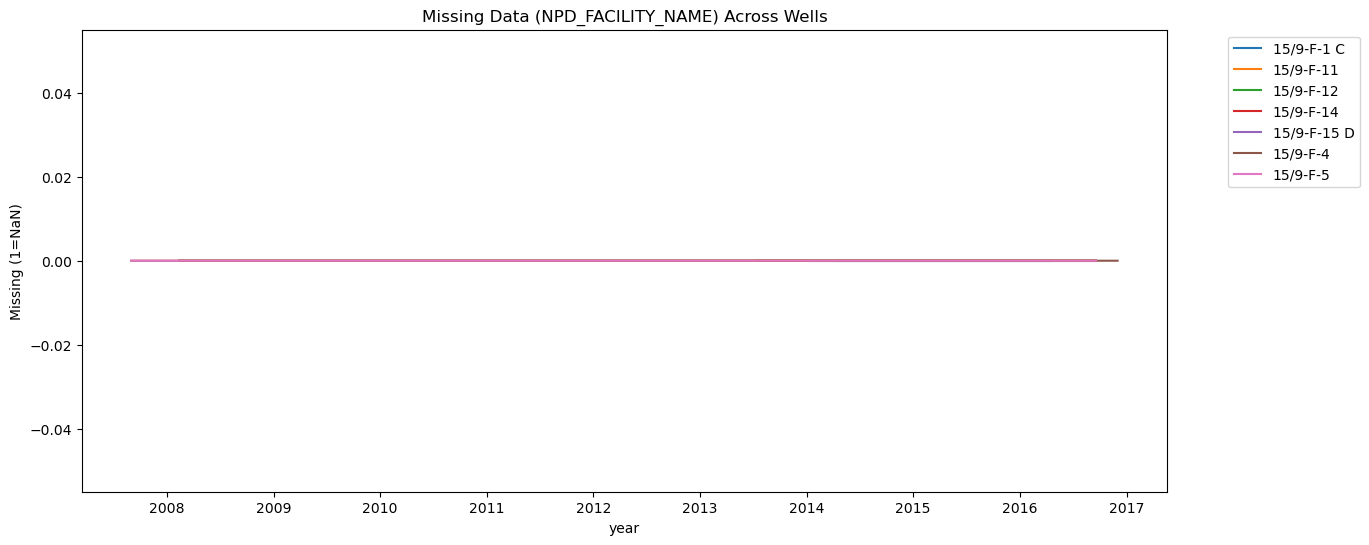

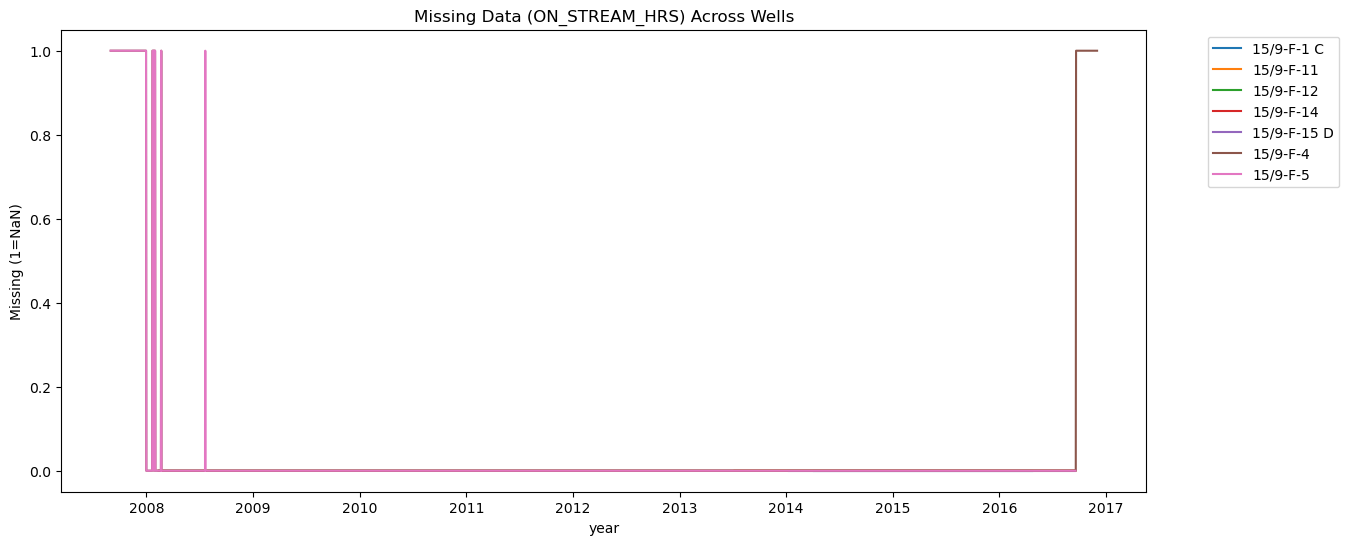

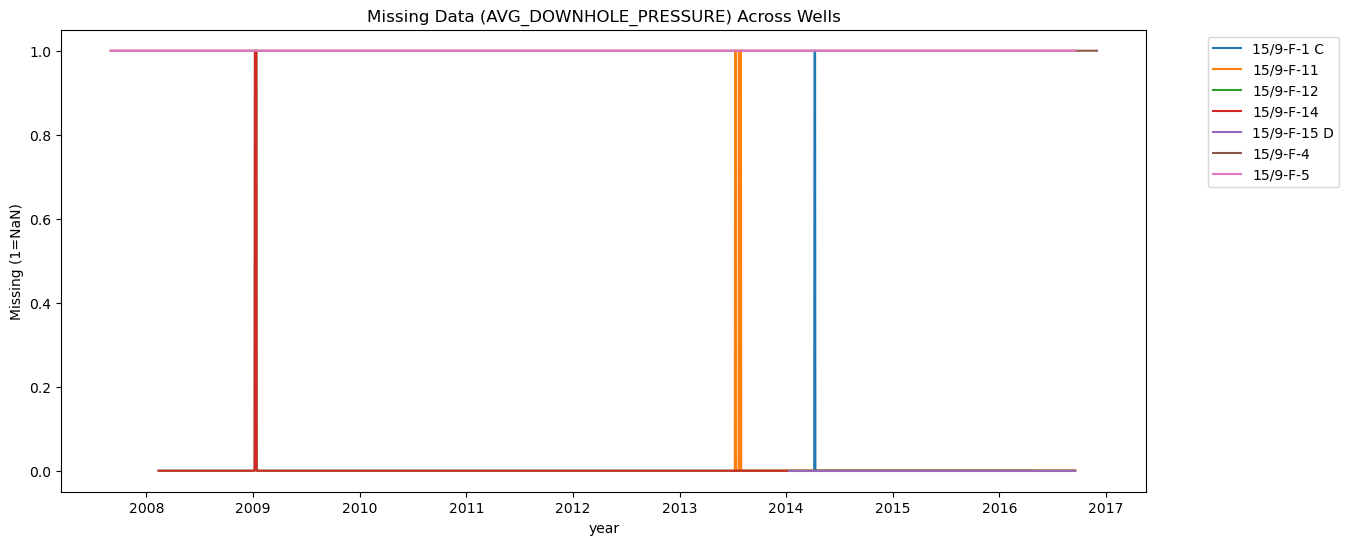

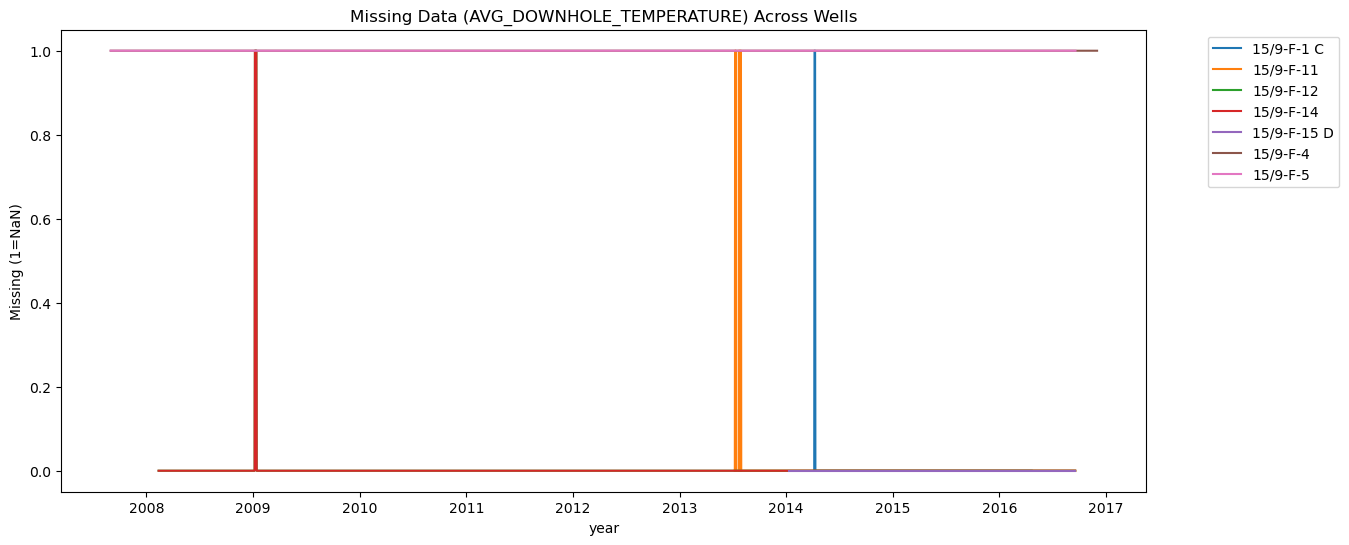

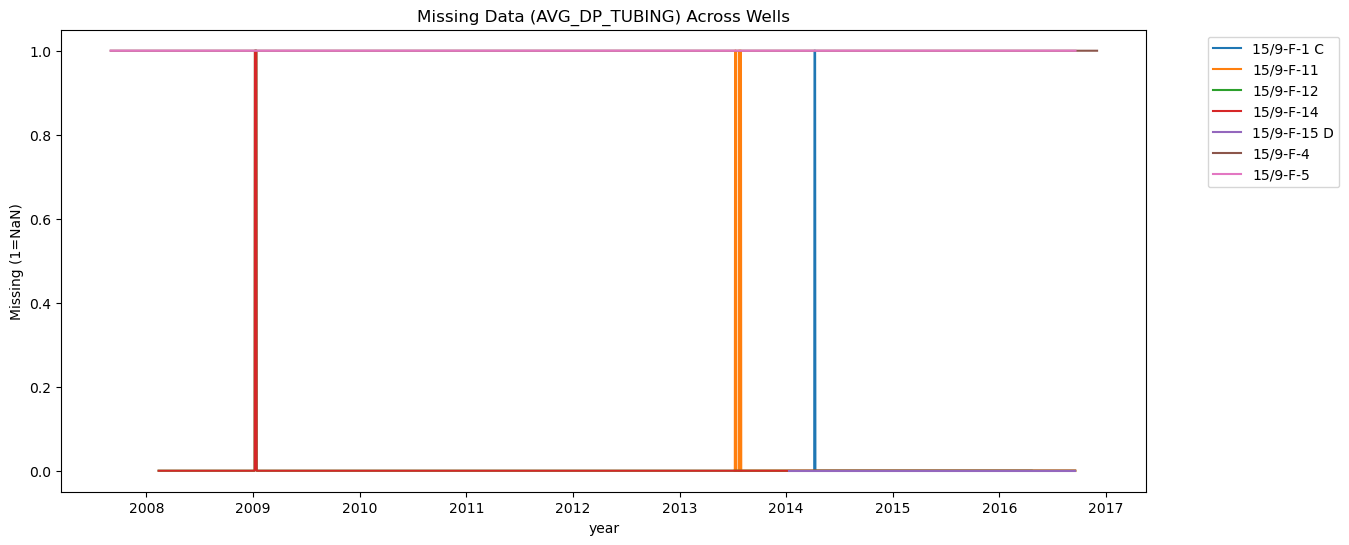

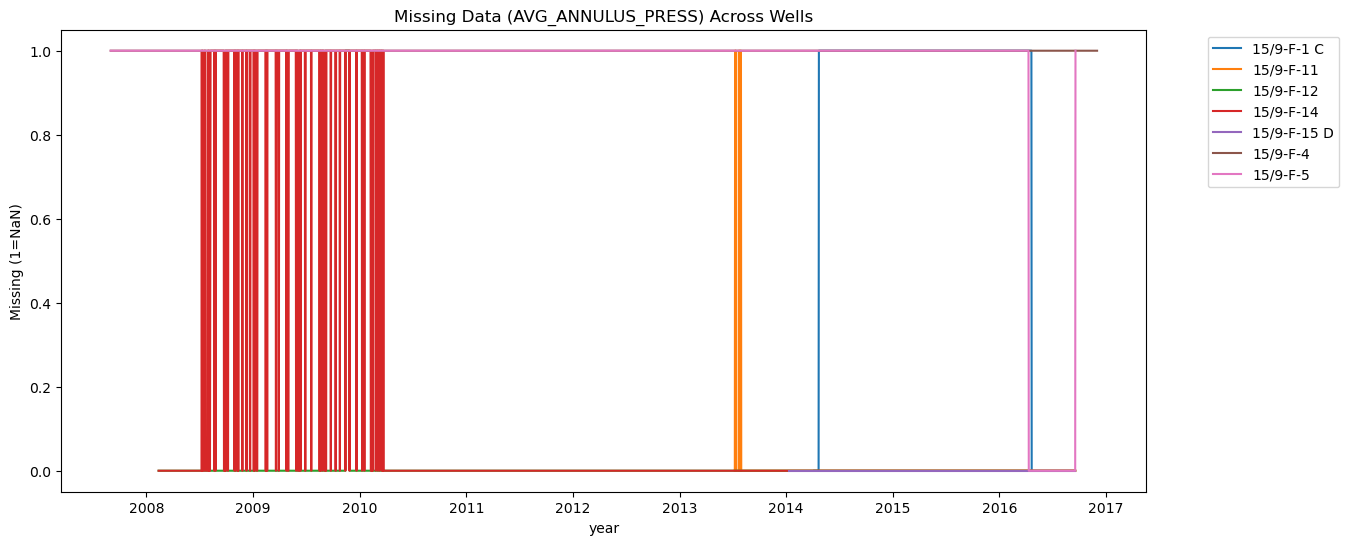

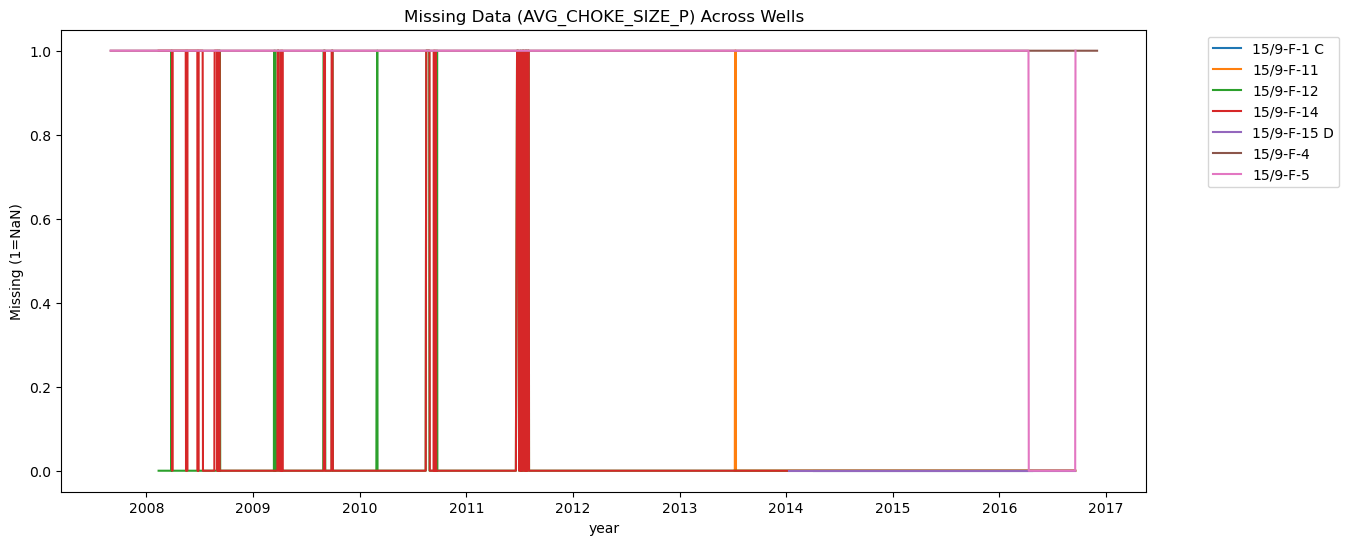

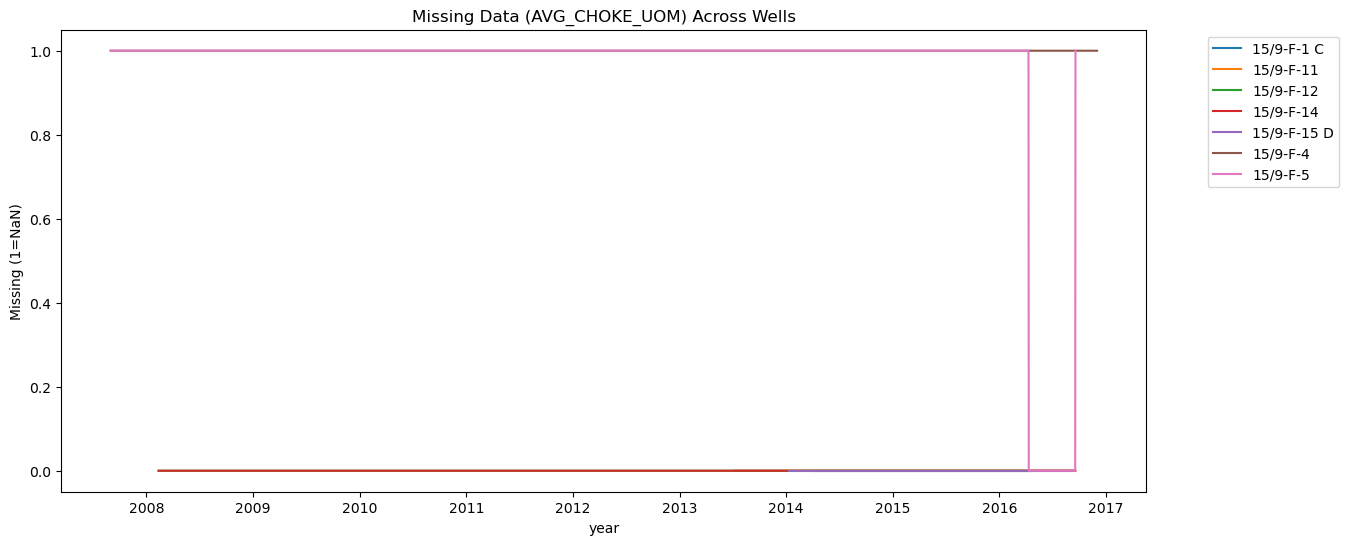

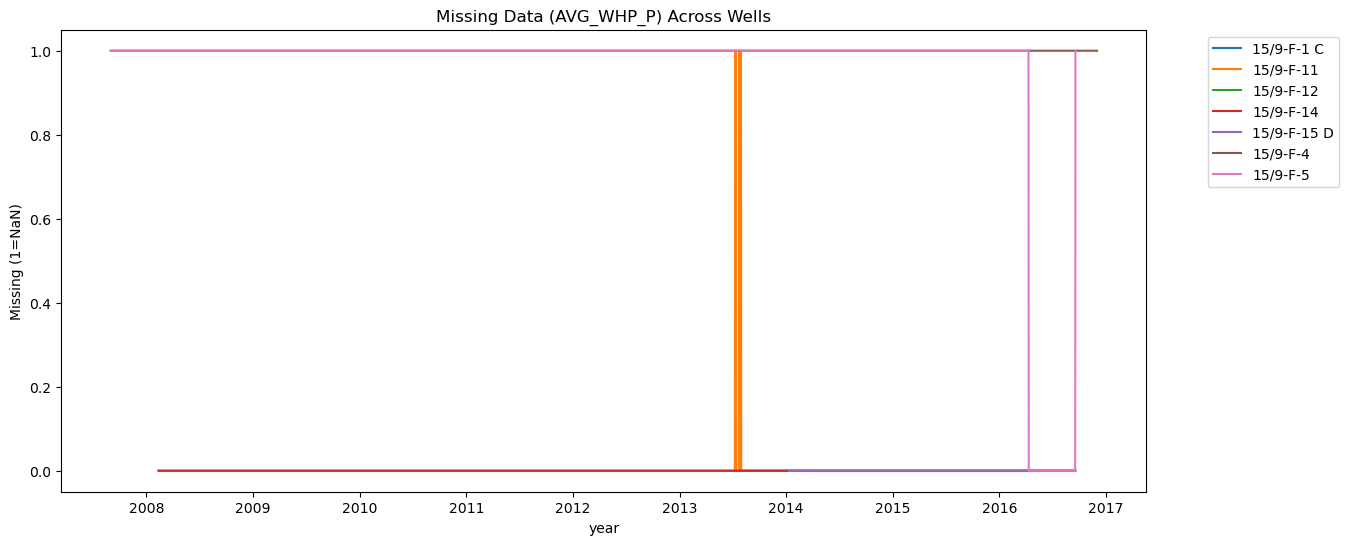

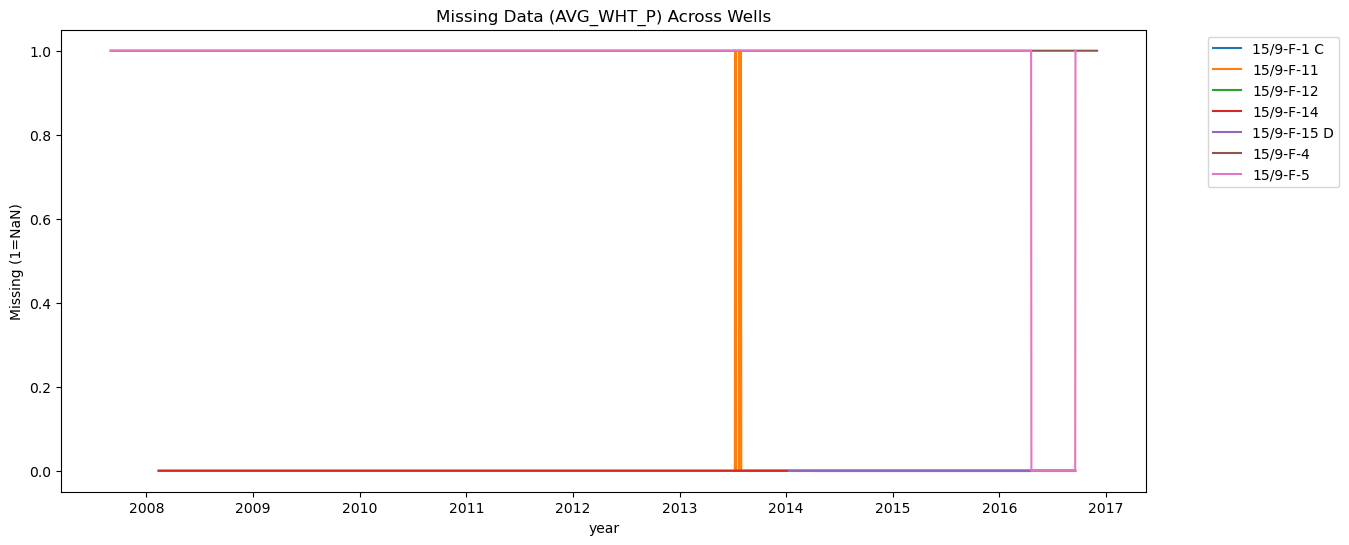

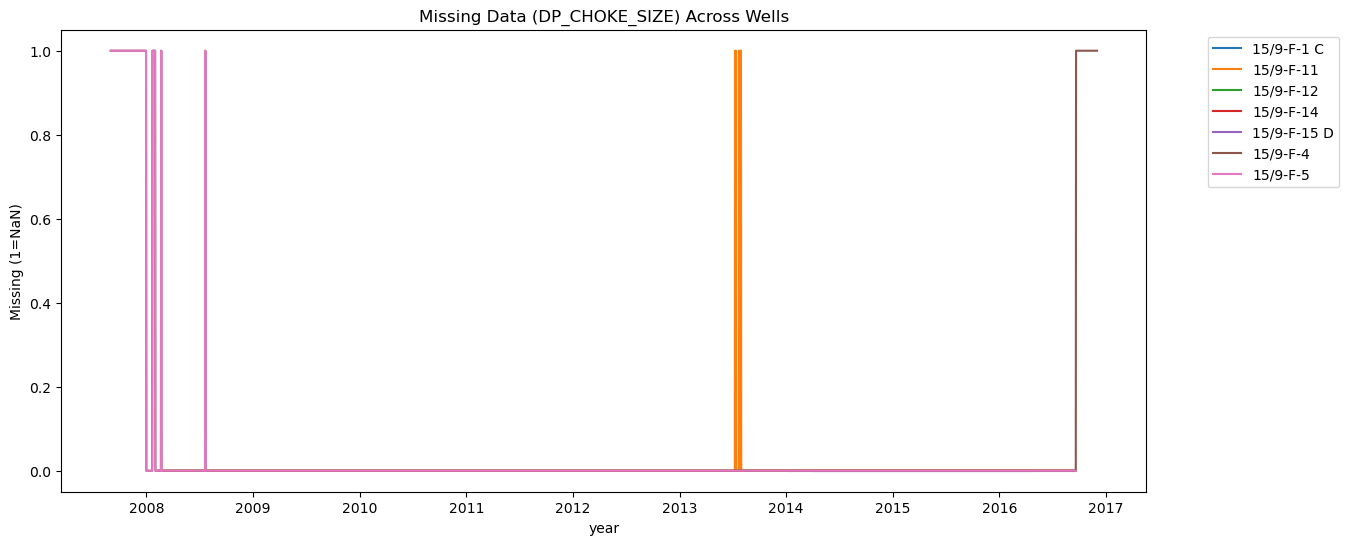

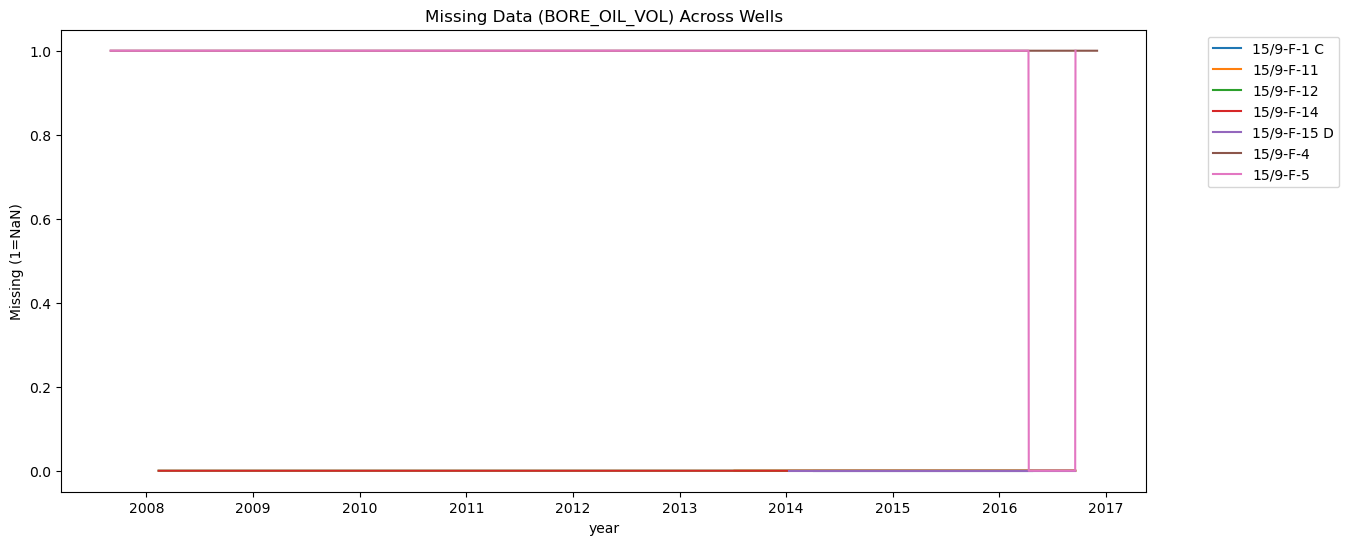

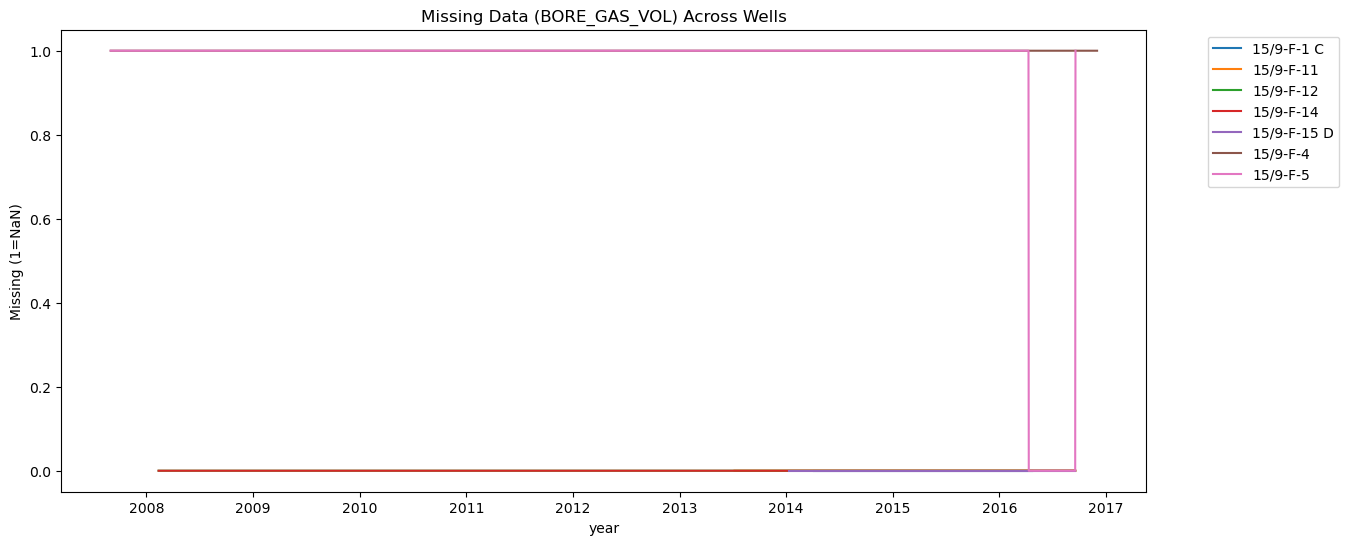

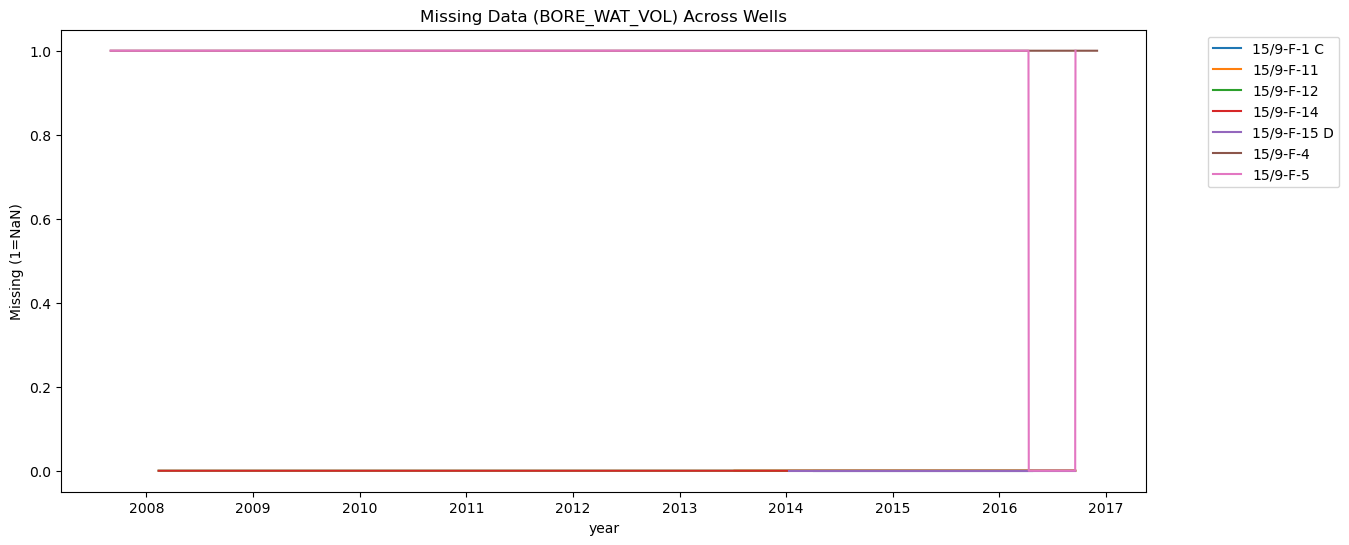

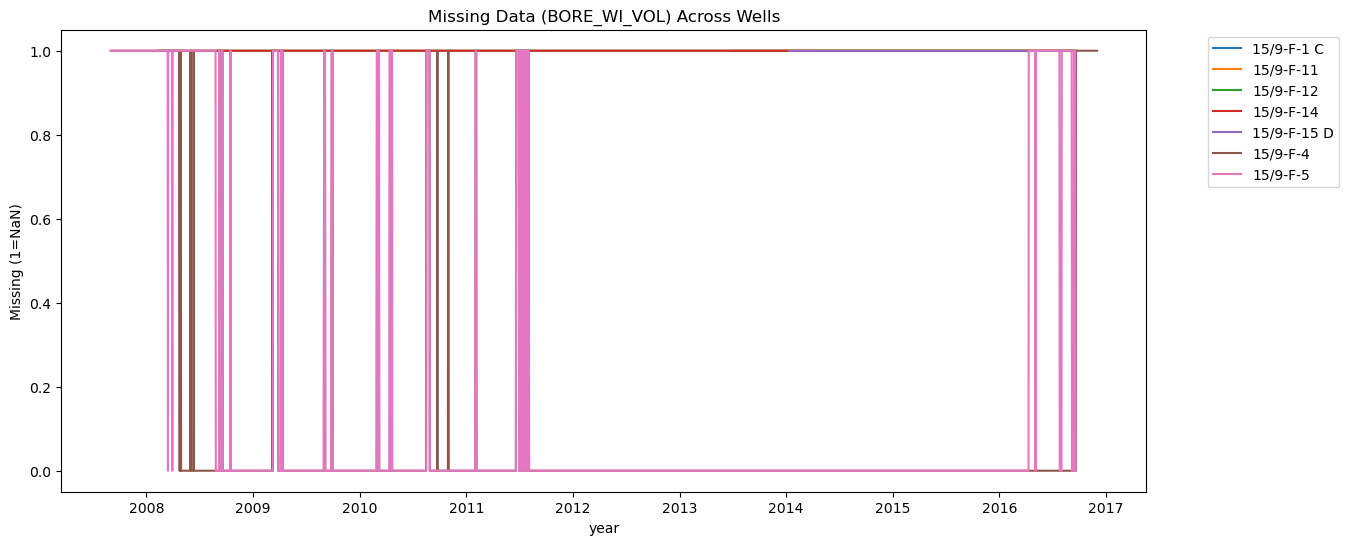

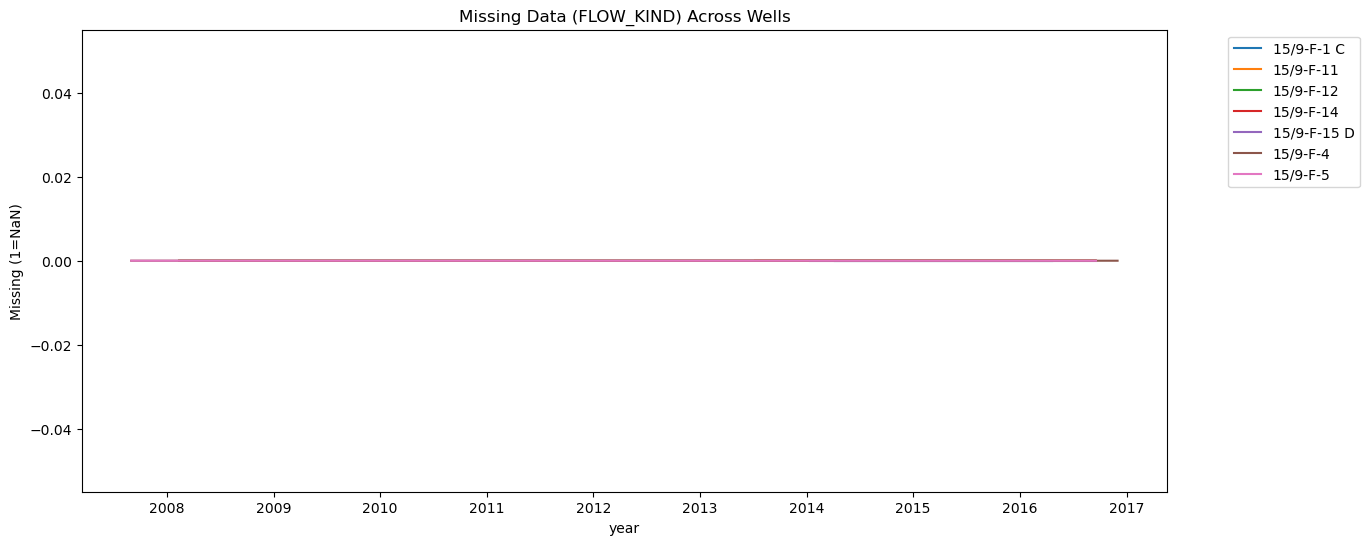

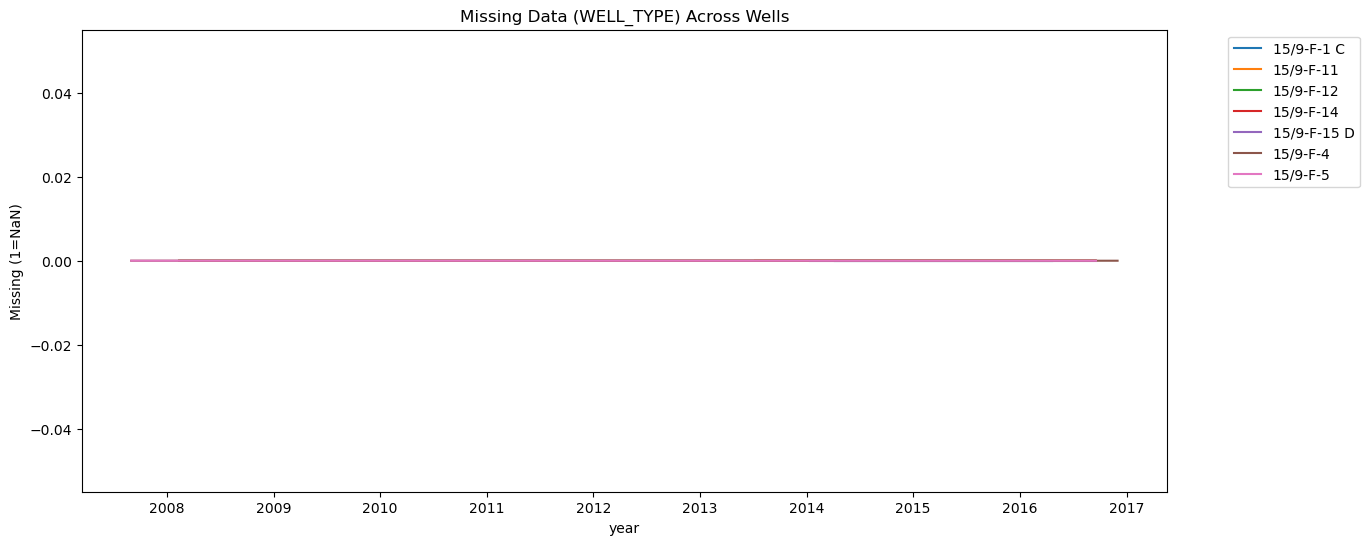

In [10]:
# I am plotting all the channels to see around what date are the data missing.
# It looks as ifa lot of the production data are missing for 15/9-F-4, 15/9-F-5. There might be more that are overlap.
# it looks like i won't be able to do machine learning for these wells

for channelname in column_names:

    plt.figure(figsize=(14,6))

    for wellname in unique_wellnames:

        df_well = production_df[production_df["NPD_WELL_BORE_NAME"] == wellname].copy()

        x = df_well["DATEPRD"]
        y = df_well[channelname].isna().astype(int)

        sns.lineplot(x=x, y=y, label=wellname)

    plt.title(f"Missing Data ({channelname}) Across Wells")
    plt.ylabel("Missing (1=NaN)")
    plt.xlabel("year")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # move legend outside
    plt.show()
    

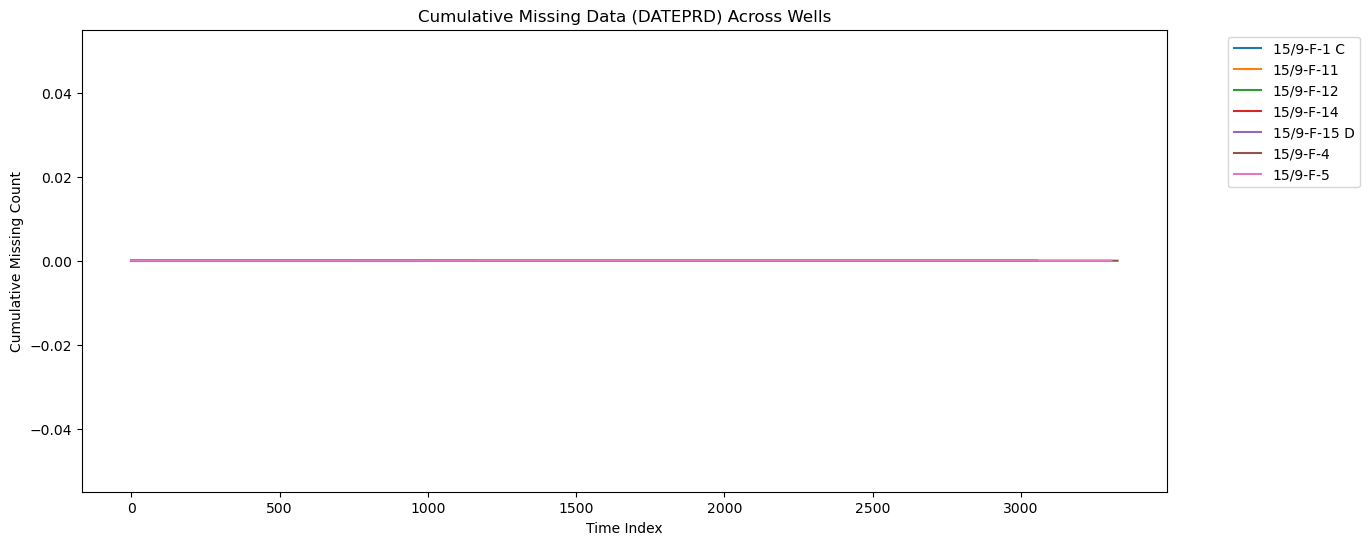

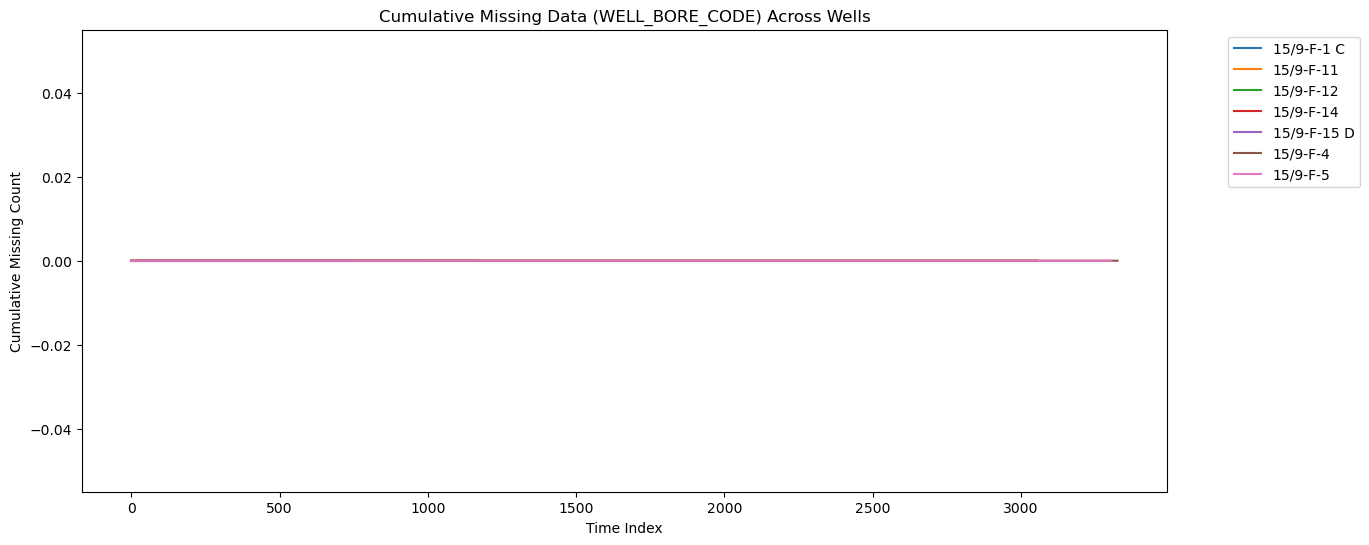

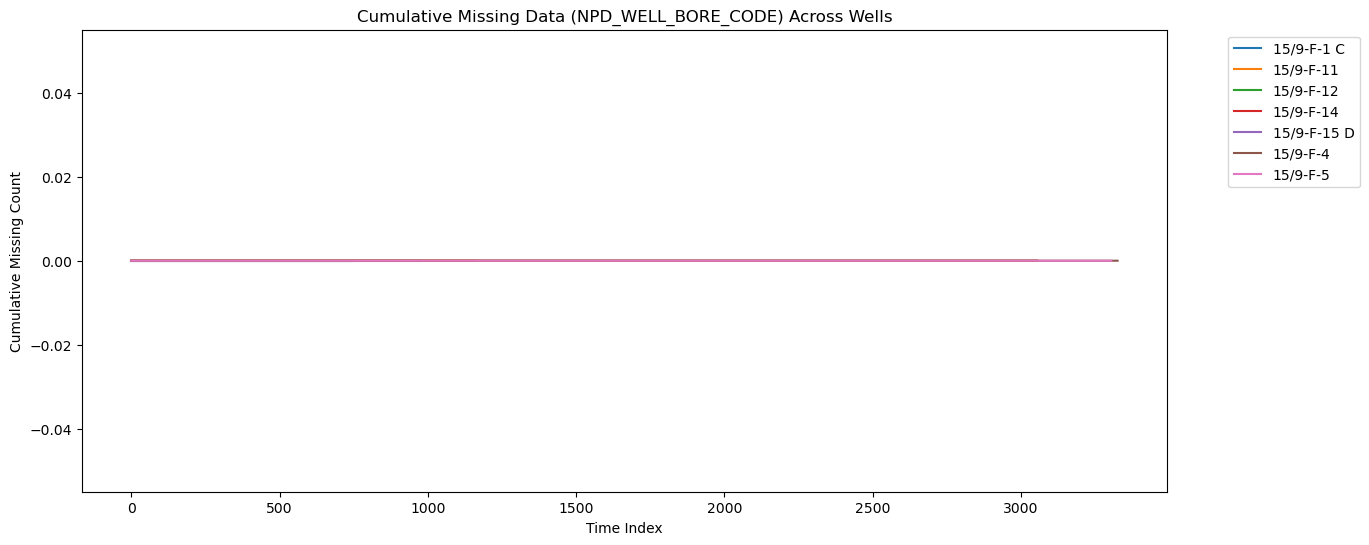

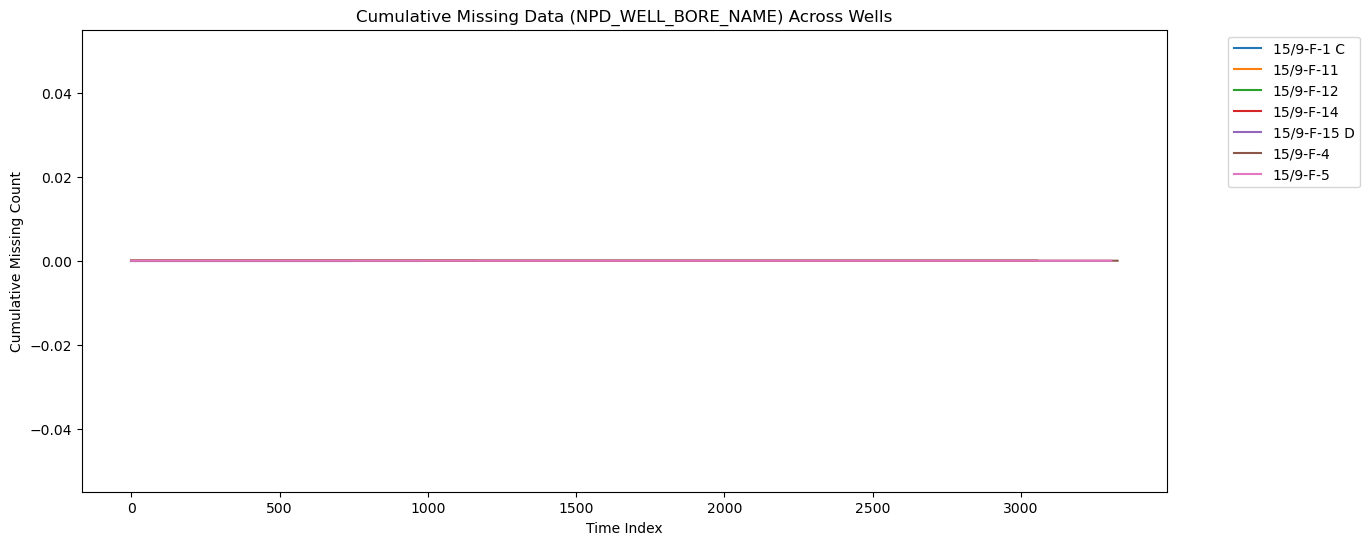

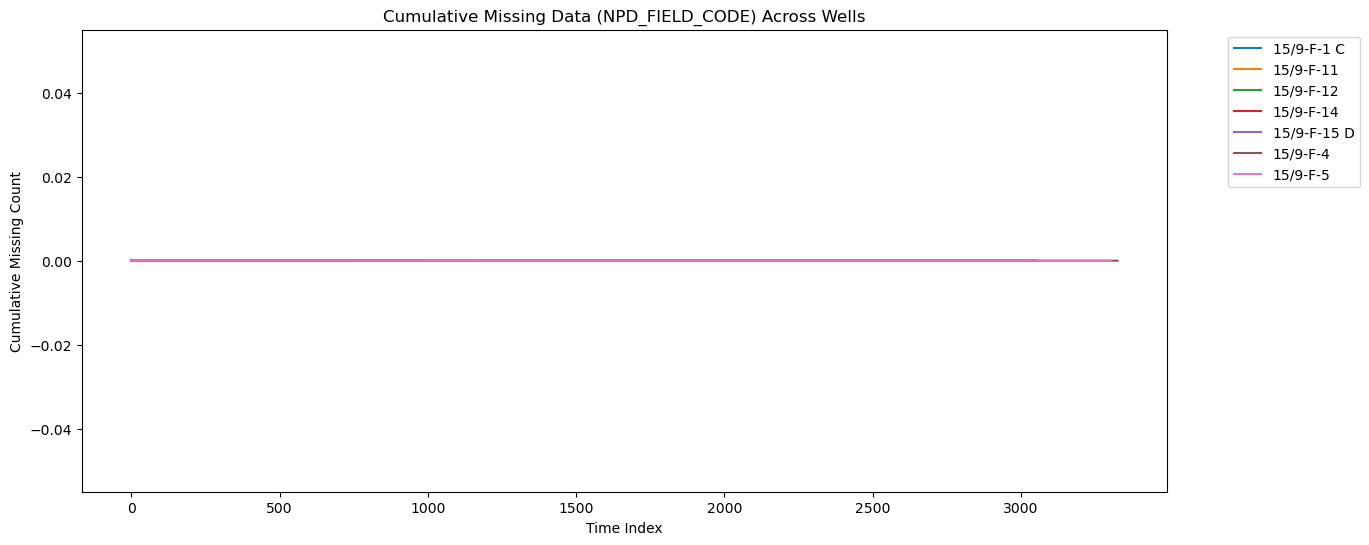

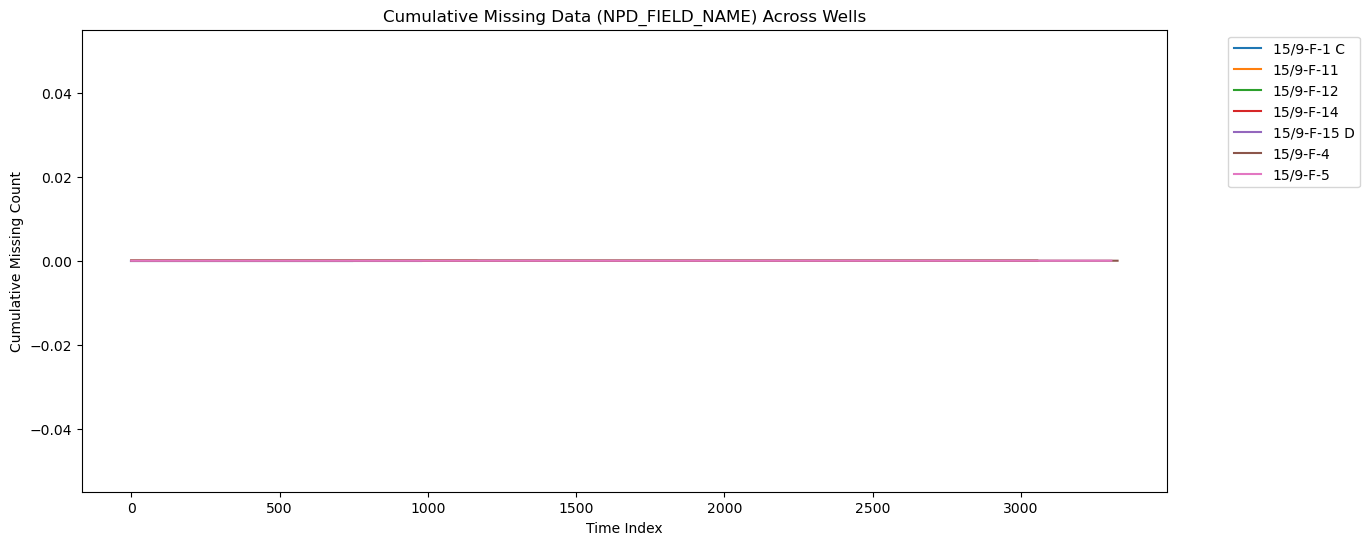

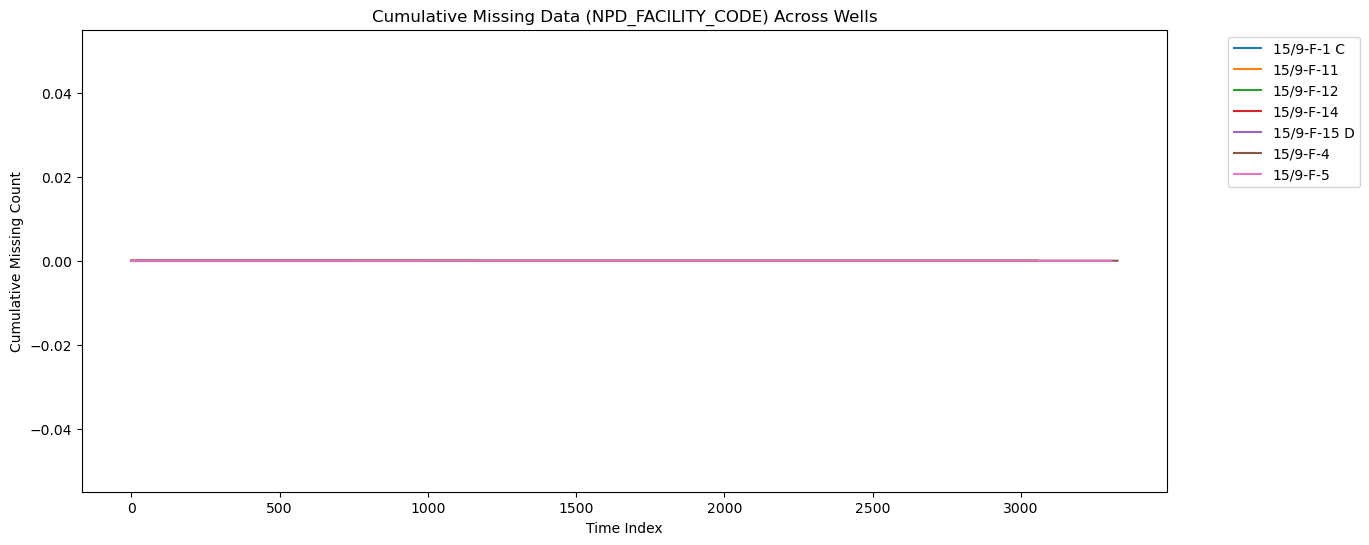

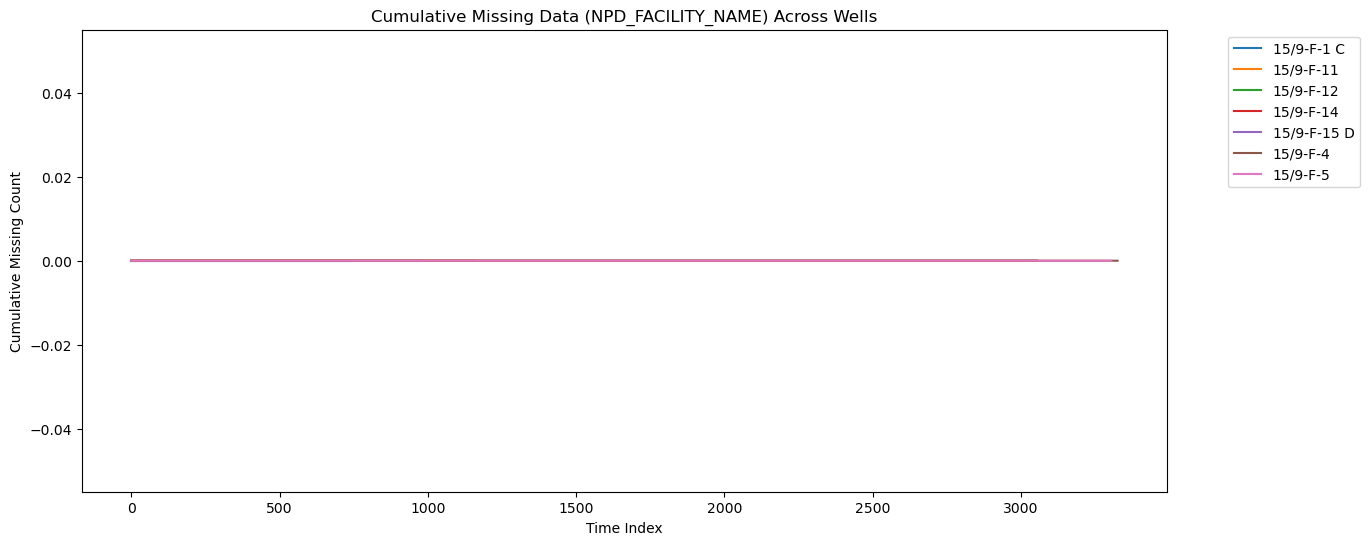

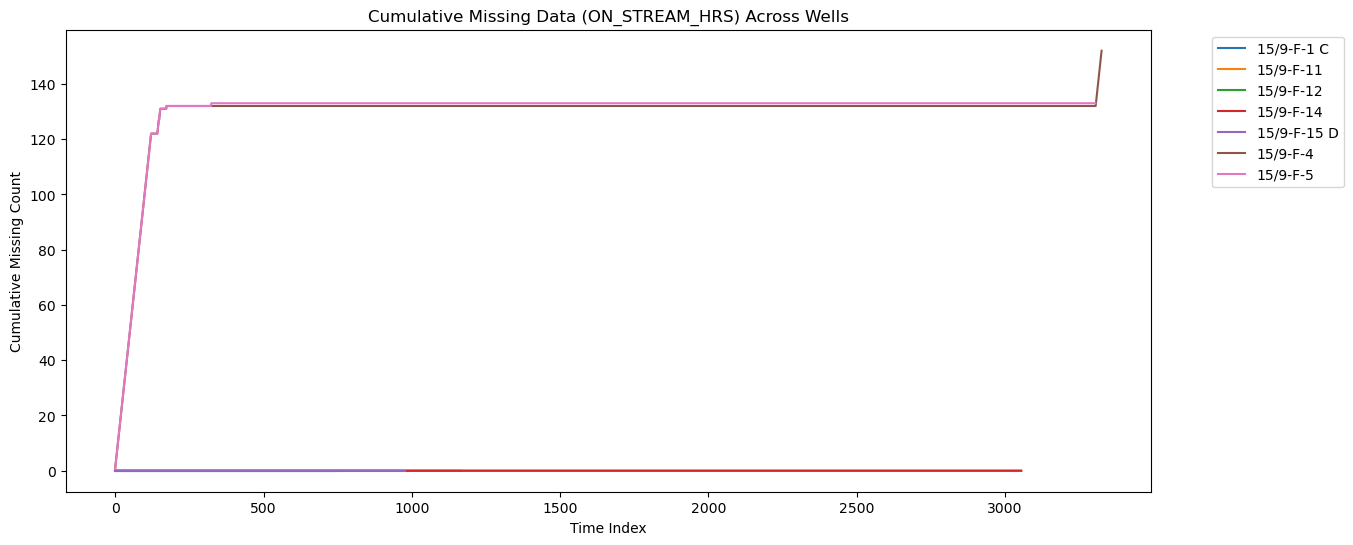

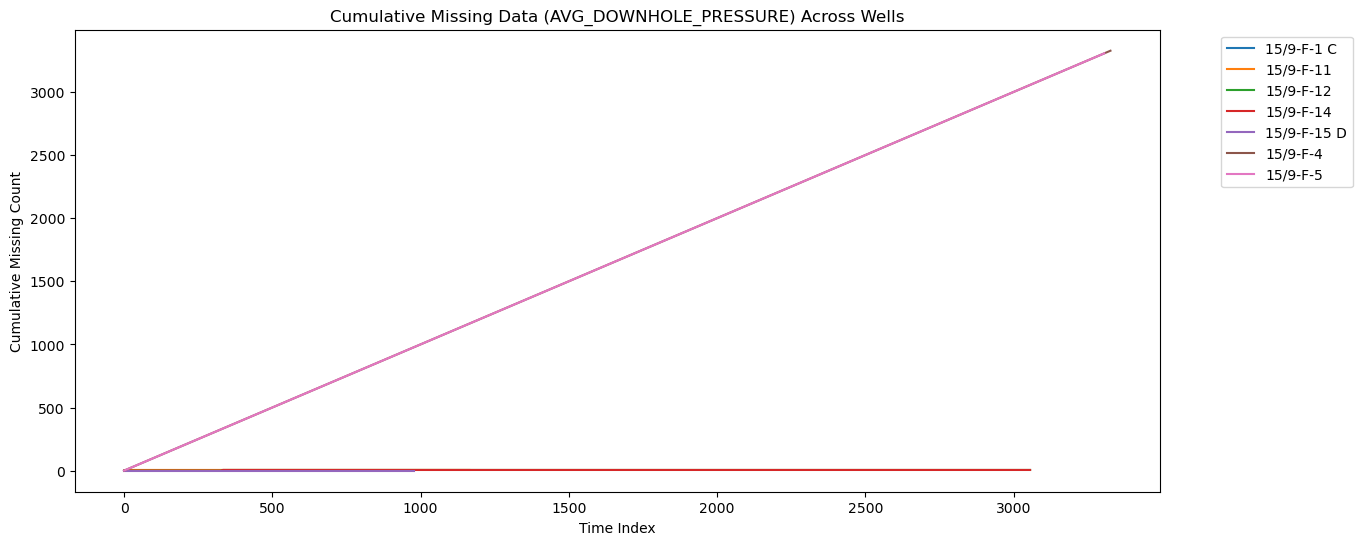

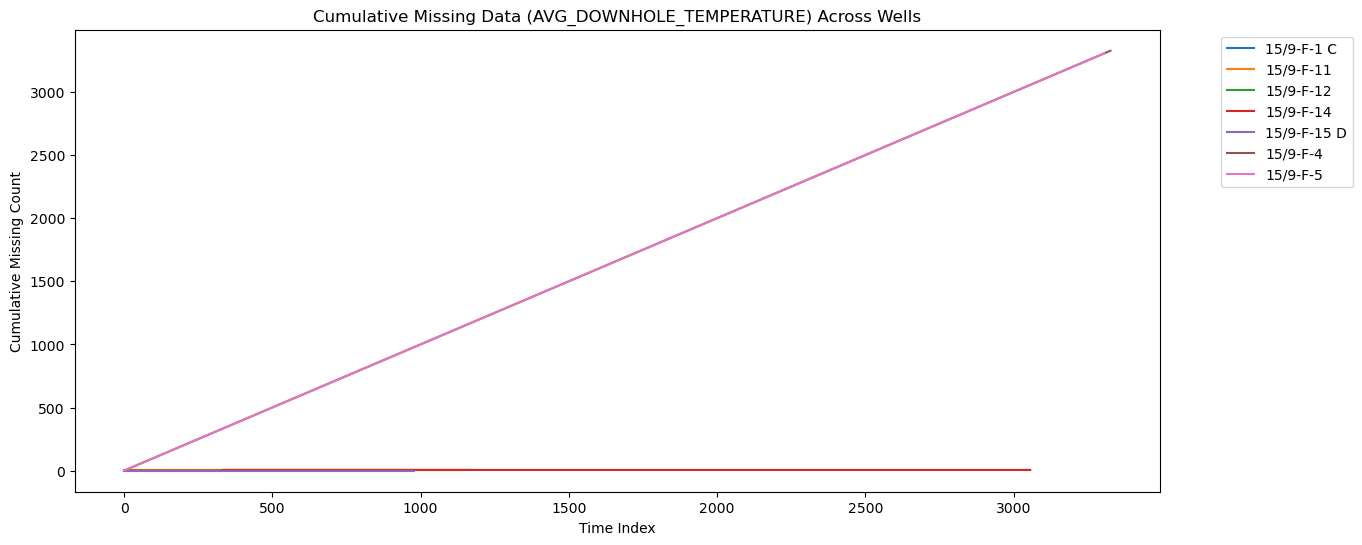

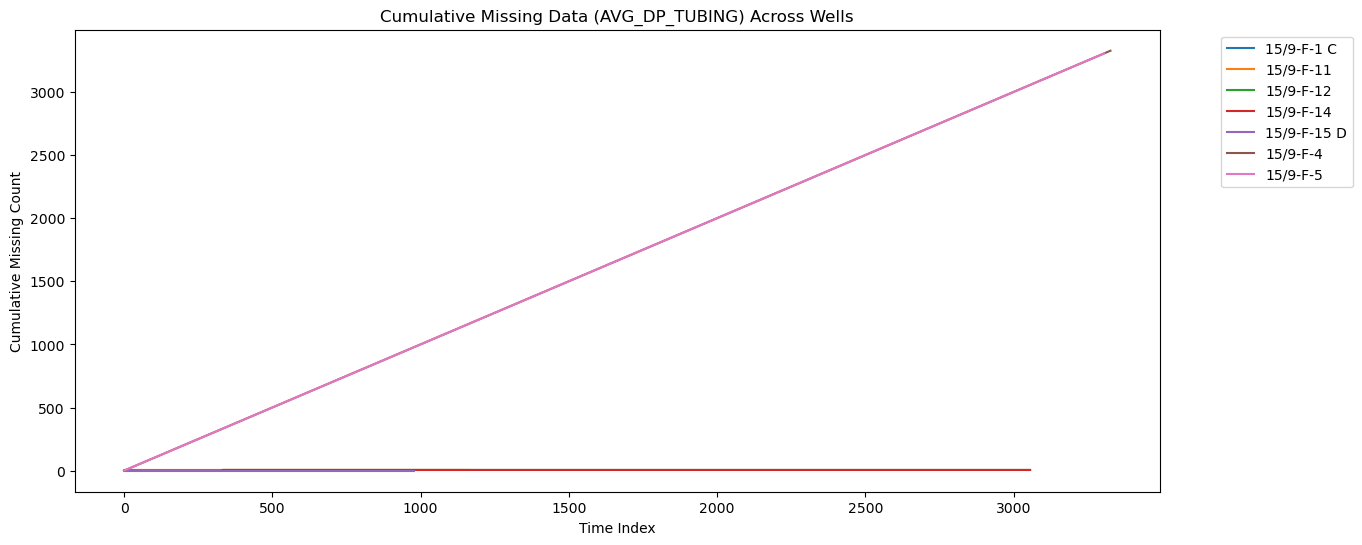

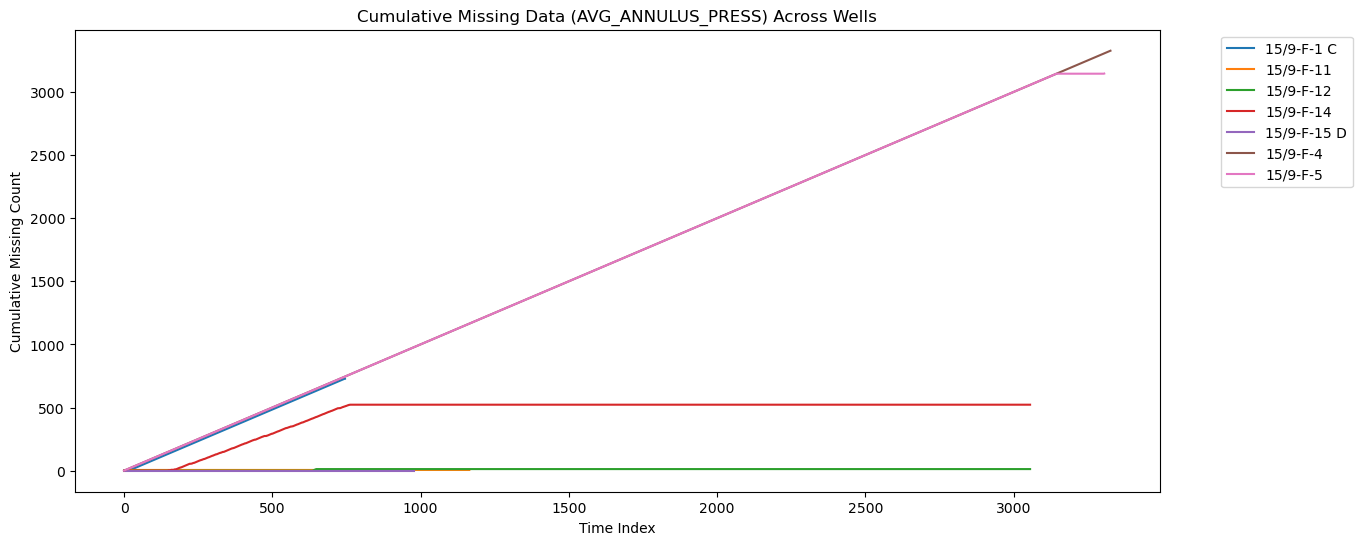

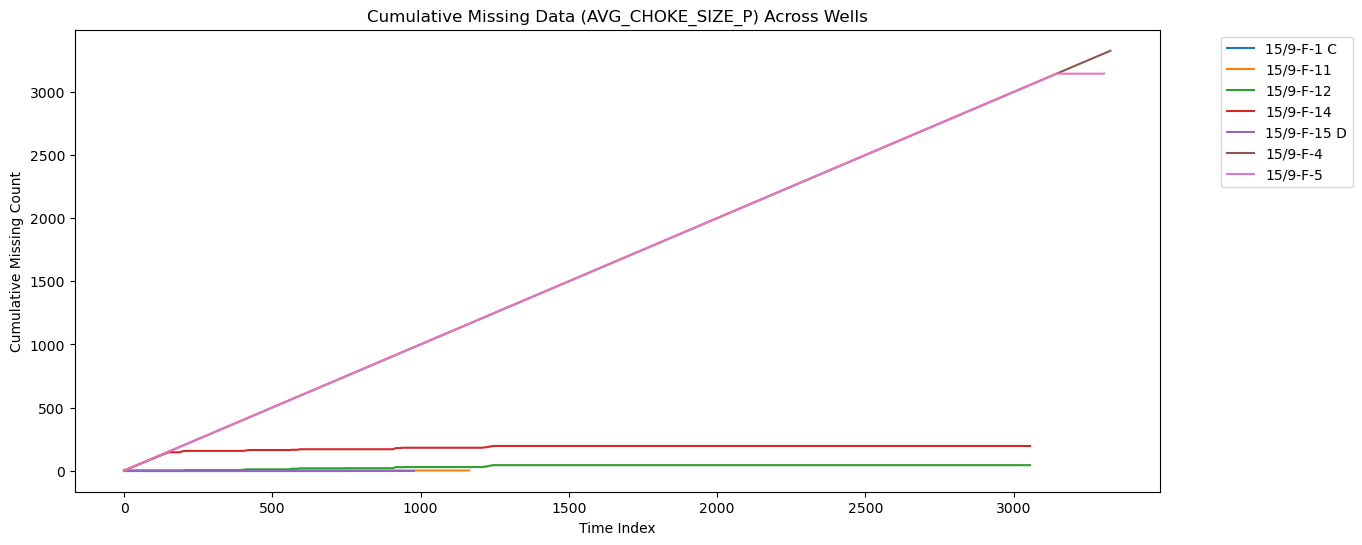

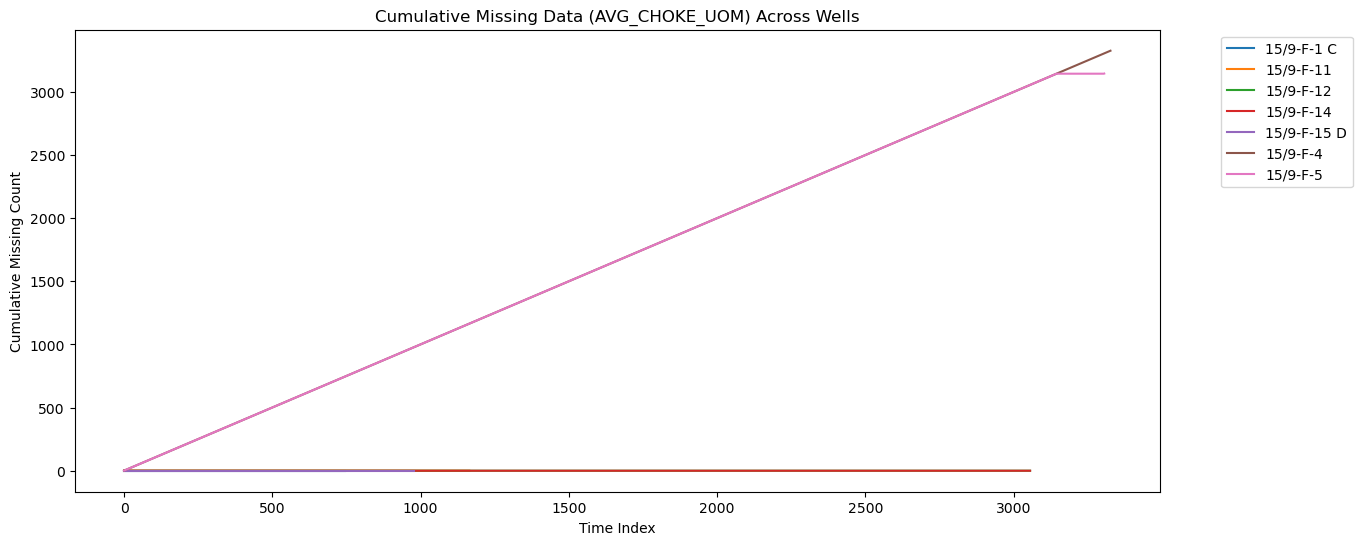

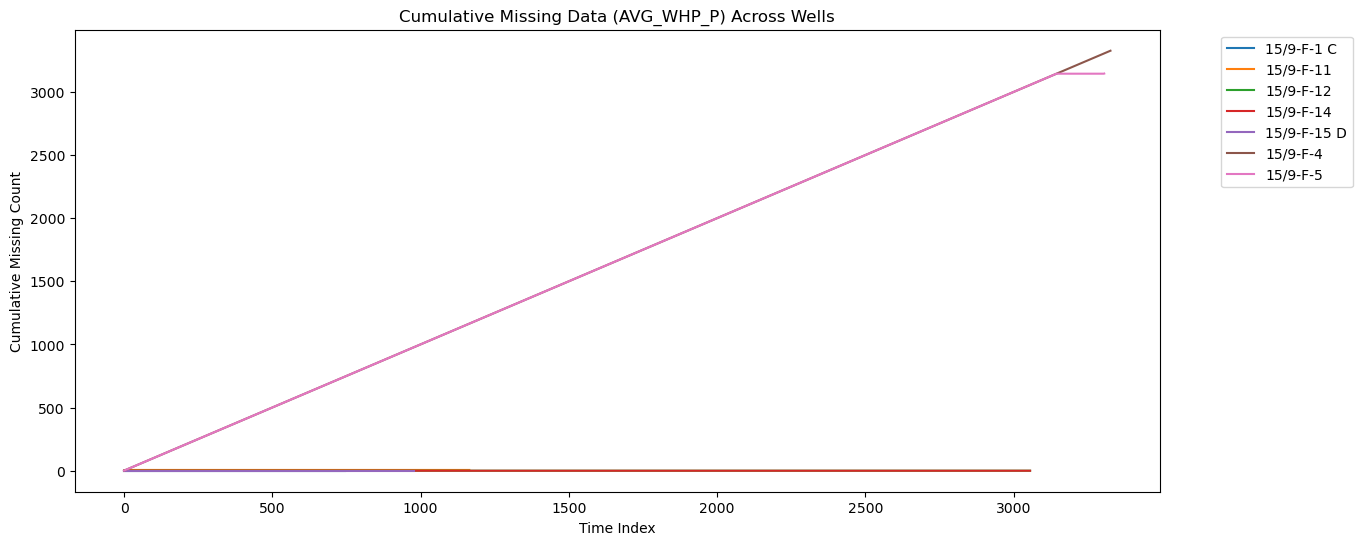

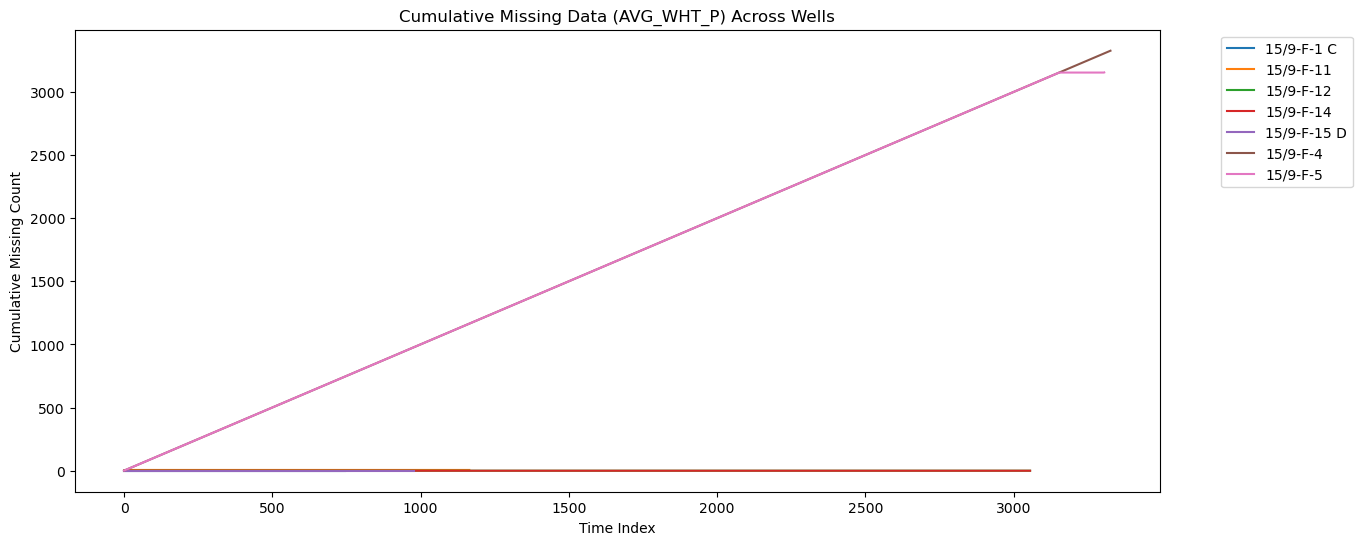

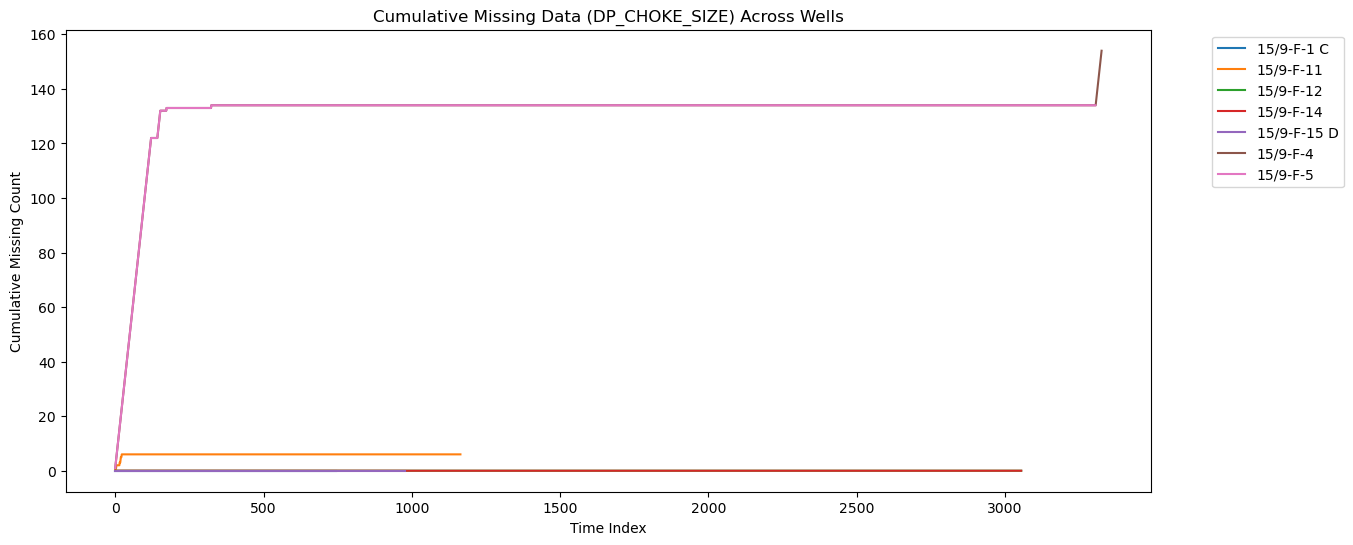

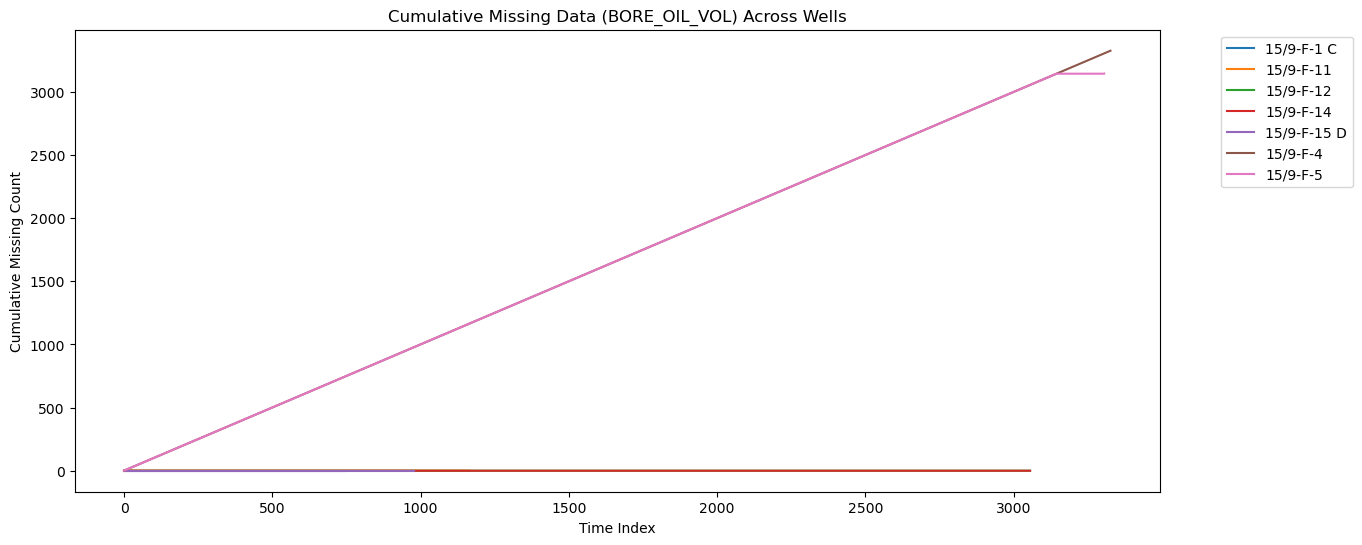

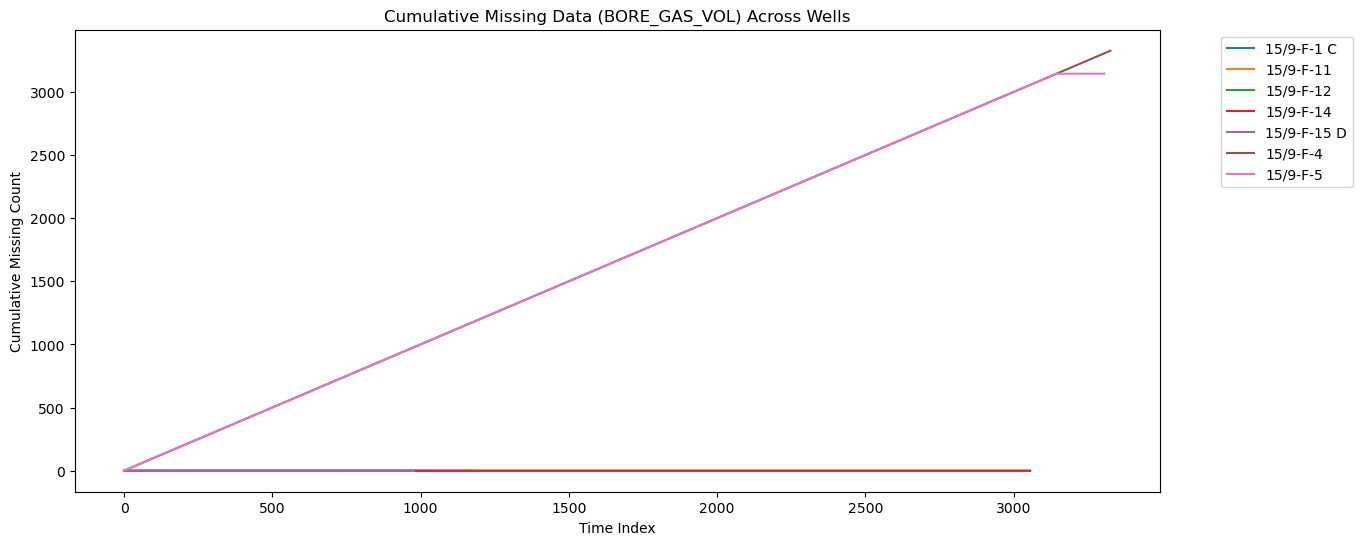

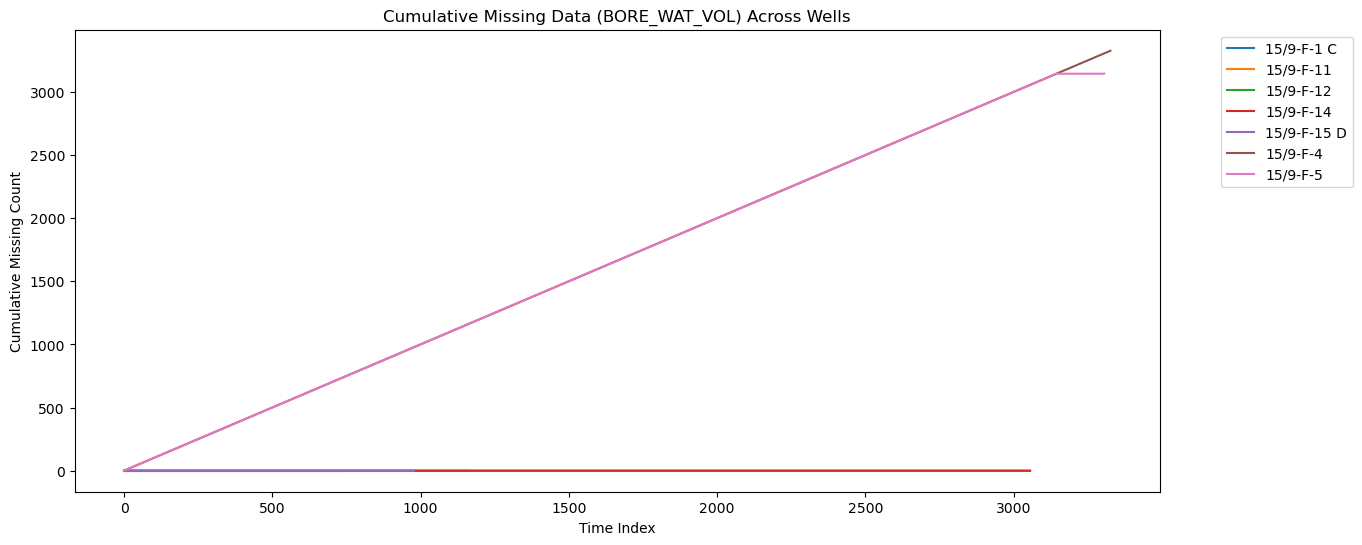

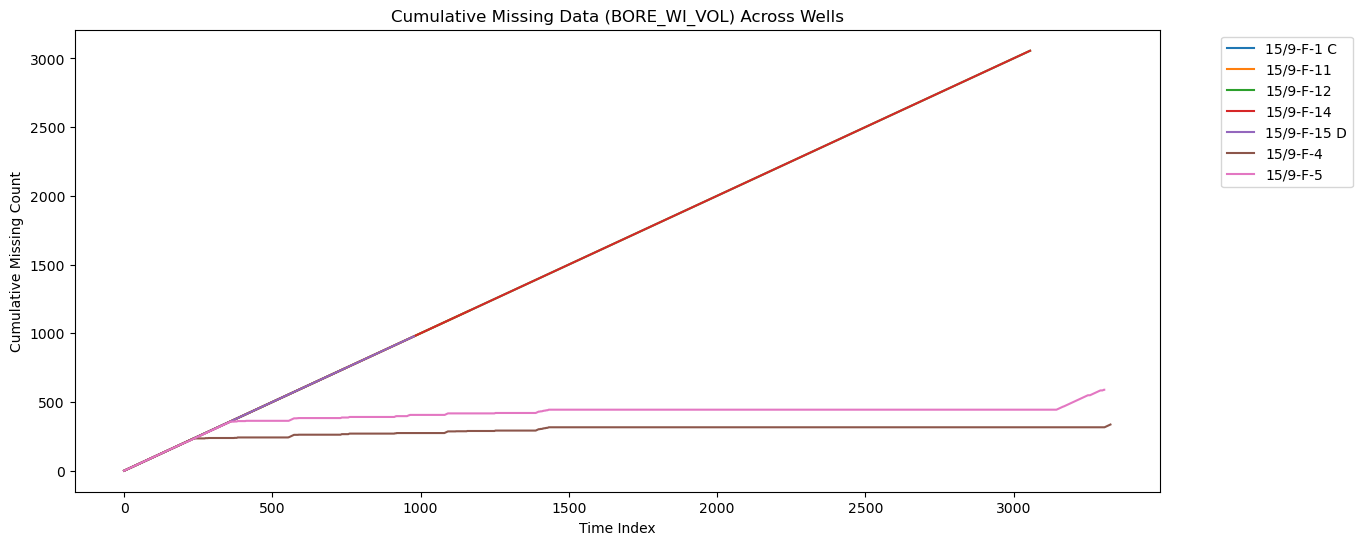

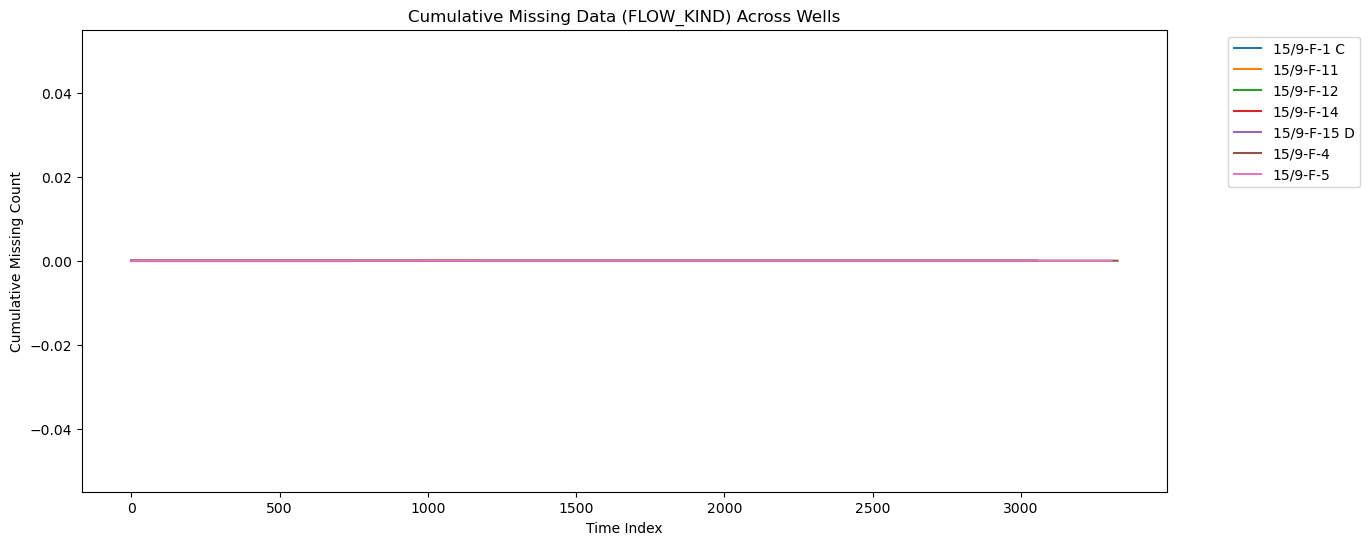

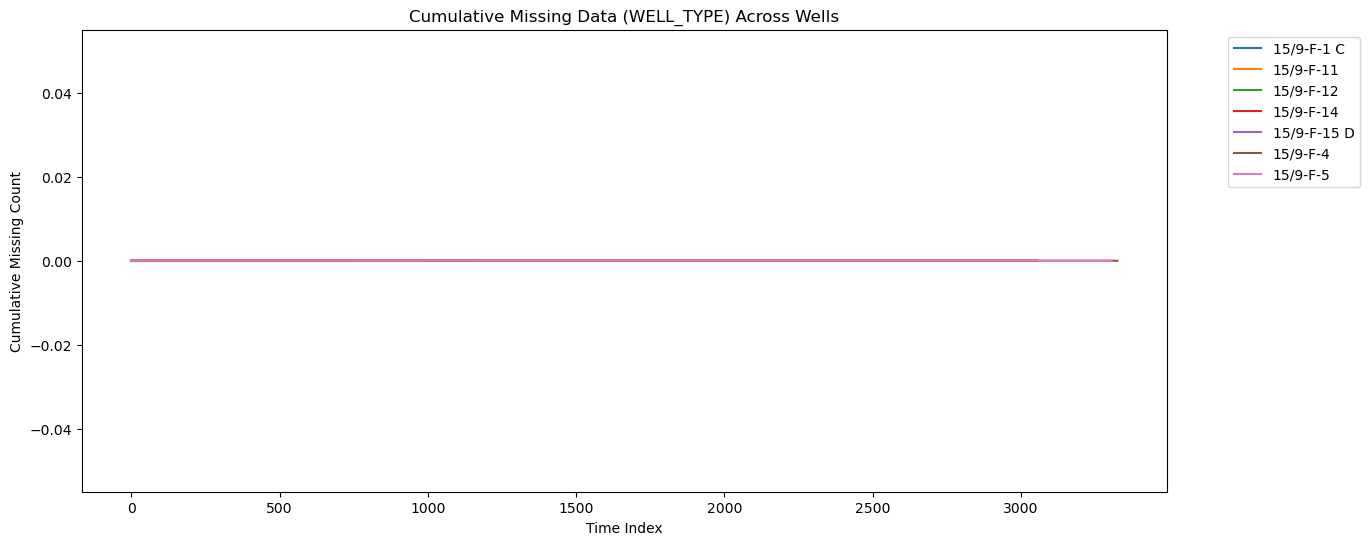

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

for channelname in column_names:

    plt.figure(figsize=(14,6))

    for wellname in unique_wellnames:

        df_well = production_df[
            production_df["NPD_WELL_BORE_NAME"] == wellname
        ].copy()

        x = df_well.reset_index().index
        
        # 👇 cumulative missing count
        y = df_well[channelname].isna().astype(int).cumsum()

        sns.lineplot(x=x, y=y, label=wellname)

    plt.title(f"Cumulative Missing Data ({channelname}) Across Wells")
    plt.ylabel("Cumulative Missing Count")
    plt.xlabel("Time Index")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

## Convert from metric unit to field

In [12]:
# liquid volumes: Sm3/day to STB/day
production_df_field=pd.DataFrame()
production_df_field["DATEPRD"] = production_df["DATEPRD"] 
production_df_field["WELL_BORE_CODE"] = production_df["WELL_BORE_CODE"]
production_df_field["NPD_WELL_BORE_CODE"] = production_df["NPD_WELL_BORE_CODE"] 
production_df_field["NPD_WELL_BORE_NAME"] = production_df["NPD_WELL_BORE_NAME"] 
production_df_field["NPD_FIELD_CODE"] = production_df["NPD_FIELD_CODE"] 
production_df_field["NPD_FIELD_NAME"] = production_df["NPD_FIELD_NAME"] 
production_df_field["NPD_FACILITY_CODE"] = production_df["NPD_FACILITY_CODE"] 
production_df_field["NPD_FACILITY_NAME"] = production_df["NPD_FACILITY_NAME"] 
production_df_field["ON_STREAM_HRS"] = production_df["ON_STREAM_HRS"] 
production_df_field["AVG_DOWNHOLE_PRESSURE_PSI"] = production_df["AVG_DOWNHOLE_PRESSURE"] * 14.5038
production_df_field["AVG_DOWNHOLE_TEMPERATURE_F"] = production_df["AVG_DOWNHOLE_TEMPERATURE"] * 9/5 + 32
production_df_field["AVG_DP_TUBING_PSI"] = production_df["AVG_DP_TUBING"] * 14.5038
production_df_field["AVG_ANNULUS_PRESS_PSI"] = production_df["AVG_ANNULUS_PRESS"] * 14.5038
production_df_field["AVG_CHOKE_SIZE_P"] = production_df["AVG_CHOKE_SIZE_P"] 
production_df_field["AVG_CHOKE_UOM"] = production_df["AVG_CHOKE_UOM"] 
production_df_field["AVG_WHP_P_PSI"] = production_df["AVG_WHP_P"]* 14.5038 
production_df_field["AVG_WHT_P"] = production_df["AVG_WHT_P"]* 9/5 + 32 
production_df_field["DP_CHOKE_SIZE"] = production_df["DP_CHOKE_SIZE"] 
production_df_field["BORE_OIL_VOL_STB_D"] = production_df["BORE_OIL_VOL"]* 6.28981
production_df_field["BORE_GAS_VOL"] = production_df["BORE_GAS_VOL"] * 35.3147/1000 
production_df_field["BORE_WAT_VOL_STB_D"] = production_df["BORE_WAT_VOL"]* 6.28981
production_df_field["BORE_WI_VOL"] = production_df["BORE_WI_VOL"]
production_df_field["FLOW_KIND"] = production_df["FLOW_KIND"]
production_df_field["WELL_TYPE"] = production_df["WELL_TYPE"]



In [13]:
len(production_df_field.columns)

24

In [14]:
len(production_df.columns)

24

## Calculate Cummulative production and timezero, normalized time

In [15]:
production_df["Time_zero"]=(production_df.groupby("NPD_WELL_BORE_NAME")["DATEPRD"].transform("min"))

In [16]:
#Normalized time to time zero
production_df["Normalized_Time"]=(production_df["DATEPRD"]-production_df["Time_zero"]).dt.days.astype(float)

In [17]:
#Days on production no downtime
production_df["is_producing"] = (
    (production_df["BORE_OIL_VOL"] > 0) |
    (production_df["BORE_GAS_VOL"] > 0) |
    (production_df["BORE_WAT_VOL"] > 0)
)


# Days_on_prod: count only producing days, grouped by well
production_df["Days_on_prod"] = (production_df.sort_values(["NPD_WELL_BORE_NAME", "DATEPRD"]).groupby("NPD_WELL_BORE_NAME")["is_producing"].cumsum())-0

In [18]:
# calculate cummulative production
production_df["Cummulative_Oil_VOL"] = production_df.sort_values(["NPD_WELL_BORE_NAME", "DATEPRD"]).groupby("NPD_WELL_BORE_NAME")["BORE_OIL_VOL"].cumsum()
production_df["Cummulative_Gas_VOL"] = production_df.sort_values(["NPD_WELL_BORE_NAME", "DATEPRD"]).groupby("NPD_WELL_BORE_NAME")["BORE_GAS_VOL"].cumsum()
production_df["Cummulative_WAT_VOL"] = production_df.sort_values(["NPD_WELL_BORE_NAME", "DATEPRD"]).groupby("NPD_WELL_BORE_NAME")["BORE_WAT_VOL"].cumsum()


In [19]:
production_df

,DATEPRD,WELL_BORE_CODE,NPD_WELL_BORE_CODE,NPD_WELL_BORE_NAME,NPD_FIELD_CODE,NPD_FIELD_NAME,NPD_FACILITY_CODE,NPD_FACILITY_NAME,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,...,BORE_WI_VOL,FLOW_KIND,WELL_TYPE,Time_zero,Normalized_Time,is_producing,Days_on_prod,Cummulative_Oil_VOL,Cummulative_Gas_VOL,Cummulative_WAT_VOL
0,2014-04-07,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,0.00000,...,NaN,production,WI,2014-04-07,0.0,False,0,0.00,0.00,0.00
1,2014-04-08,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,NaN,production,OP,2014-04-07,1.0,False,0,0.00,0.00,0.00
2,2014-04-09,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,NaN,production,OP,2014-04-07,2.0,False,0,0.00,0.00,0.00
3,2014-04-10,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,NaN,production,OP,2014-04-07,3.0,False,0,0.00,0.00,0.00
4,2014-04-11,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,310.37614,...,NaN,production,OP,2014-04-07,4.0,False,0,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15629,2016-09-14,NO 15/9-F-5 AH,5769,15/9-F-5,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,NaN,production,OP,2007-09-01,3301.0,False,129,41160.68,6561825.74,13533.18
15630,2016-09-15,NO 15/9-F-5 AH,5769,15/9-F-5,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,NaN,production,OP,2007-09-01,3302.0,False,129,41160.68,6561825.74,13533.18
15631,2016-09-16,NO 15/9-F-5 AH,5769,15/9-F-5,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,NaN,production,OP,2007-09-01,3303.0,False,129,41160.68,6561825.74,13533.18
15632,2016-09-17,NO 15/9-F-5 AH,5769,15/9-F-5,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,NaN,production,OP,2007-09-01,3304.0,False,129,41160.68,6561825.74,13533.18


## Plotly Plots

In [20]:
[ '15/9-F-1 C',   '15/9-F-11',   '15/9-F-12',   '15/9-F-14', '15/9-F-15 D',
    '15/9-F-4',    '15/9-F-5']

['15/9-F-1 C',
 '15/9-F-11',
 '15/9-F-12',
 '15/9-F-14',
 '15/9-F-15 D',
 '15/9-F-4',
 '15/9-F-5']

In [21]:
# rate (VOL) vs time date plot
filter_df_well=production_df[production_df["NPD_WELL_BORE_NAME"]=='15/9-F-1 C']

# make traces for oil gas and water
trace_oil =go.Scatter(x=filter_df_well["DATEPRD"],y=filter_df_well['BORE_OIL_VOL'], mode = "lines", name= "Oil Rate", line={"color":"green"},yaxis="y2")
trace_gas =go.Scatter(x=filter_df_well["DATEPRD"],y=filter_df_well['BORE_GAS_VOL'], mode = "lines", name= "Gas Rate", line_color="Red")
trace_water =go.Scatter(x=filter_df_well["DATEPRD"],y=filter_df_well['BORE_WAT_VOL'], mode = "lines", name= "Water Rate" ,line={"color":"blue"},yaxis="y2")
trace_whp =go.Scatter(x=filter_df_well["DATEPRD"],y=filter_df_well['AVG_WHP_P'], mode = "lines", name= "WHP" ,line={"color":"purple"},yaxis="y2")

data=[trace_oil,trace_gas,trace_water,trace_whp]

layout = go.Layout(
                title = (f"Wellname {'15/9-F-1 C'}."),
                xaxis = {"title": "Time"},
                yaxis={"title": {"text": "Gas Rate", "font": {"color": "Red","size": 16}}},
                yaxis2={"title": {"text": '<span style="color:green">Oil Rate</span><br>'
                                          '<span style="color:blue">Water Rate</span><br>'
                                          '<span style="color:purple">WHP</span>', 
                                  "font": {"color": "black","size": 16}}, 
                        "tickfont":{"color":"black"},  
                        "overlaying":"y",
                        "side":"right"},
    
                hovermode = "closest"
                )

fig =go.Figure(data=data, layout=layout)
pyo.plot(fig)

'temp-plot.html'

In [22]:
# test normalized time
# rate (VOL) vs time normalized time plot
filter_df_well=production_df[production_df["NPD_WELL_BORE_NAME"]=='15/9-F-1 C']

# make traces for oil gas and water
trace_oil =go.Scatter(x=filter_df_well["Normalized_Time"],y=filter_df_well['BORE_OIL_VOL'], mode = "lines", name= "Oil Rate", line={"color":"green"},yaxis="y2")
trace_gas =go.Scatter(x=filter_df_well["Normalized_Time"],y=filter_df_well['BORE_GAS_VOL'], mode = "lines", name= "Gas Rate", line_color="Red")
trace_water =go.Scatter(x=filter_df_well["Normalized_Time"],y=filter_df_well['BORE_WAT_VOL'], mode = "lines", name= "Water Rate" ,line={"color":"blue"},yaxis="y2")
trace_whp =go.Scatter(x=filter_df_well["Normalized_Time"],y=filter_df_well['AVG_WHP_P'], mode = "lines", name= "WHP" ,line={"color":"purple"},yaxis="y2")

data=[trace_oil,trace_gas,trace_water,trace_whp]

layout = go.Layout(
                title = (f"Wellname {'15/9-F-1 C'}."),
                xaxis = {"title": "Normalized_Time"},
                yaxis={"title": {"text": "Gas Rate", "font": {"color": "Red","size": 16}}},
                yaxis2={"title": {"text": '<span style="color:green">Oil Rate</span><br>'
                                          '<span style="color:blue">Water Rate</span><br>'
                                          '<span style="color:purple">WHP</span>', 
                                  "font": {"color": "black","size": 16}}, 
                        "tickfont":{"color":"black"},  
                        "overlaying":"y",
                        "side":"right"},
    
                hovermode = "closest"
                )

fig =go.Figure(data=data, layout=layout)
pyo.plot(fig)

'temp-plot.html'

In [23]:
# test days on
# rate (VOL) vs Days_on_prod plot
filter_df_well=production_df[production_df["NPD_WELL_BORE_NAME"]=='15/9-F-1 C']

# make traces for oil gas and water
trace_oil =go.Scatter(x=filter_df_well["Days_on_prod"],y=filter_df_well['BORE_OIL_VOL'], mode = "lines", name= "Oil Rate", line={"color":"green"},yaxis="y2")
trace_gas =go.Scatter(x=filter_df_well["Days_on_prod"],y=filter_df_well['BORE_GAS_VOL'], mode = "lines", name= "Gas Rate", line_color="Red")
trace_water =go.Scatter(x=filter_df_well["Days_on_prod"],y=filter_df_well['BORE_WAT_VOL'], mode = "lines", name= "Water Rate" ,line={"color":"blue"},yaxis="y2")
trace_whp =go.Scatter(x=filter_df_well["Days_on_prod"],y=filter_df_well['AVG_WHP_P'], mode = "lines", name= "WHP" ,line={"color":"purple"},yaxis="y2")

data=[trace_oil,trace_gas,trace_water,trace_whp]

layout = go.Layout(
                title = (f"Wellname {'15/9-F-1 C'}."),
                xaxis = {"title": "Days_on_prod"},
                yaxis={"title": {"text": "Gas Rate", "font": {"color": "Red","size": 16}}},
                yaxis2={"title": {"text": '<span style="color:green">Oil Rate</span><br>'
                                          '<span style="color:blue">Water Rate</span><br>'
                                          '<span style="color:purple">WHP</span>', 
                                  "font": {"color": "black","size": 16}}, 
                        "tickfont":{"color":"black"},  
                        "overlaying":"y",
                        "side":"right"},
    
                hovermode = "closest"
                )

fig =go.Figure(data=data, layout=layout)
pyo.plot(fig)

'temp-plot.html'

In [24]:
# cummulative on
# rate (VOL) vs Days_on_prod plot
filter_df_well=production_df[production_df["NPD_WELL_BORE_NAME"]=='15/9-F-1 C']

# make traces for oil gas and water
trace_oil =go.Scatter(x=filter_df_well["Days_on_prod"],y=filter_df_well['Cummulative_Oil_VOL'], mode = "lines", name= "Oil Rate", line={"color":"green"},yaxis="y2")
trace_gas =go.Scatter(x=filter_df_well["Days_on_prod"],y=filter_df_well['Cummulative_Gas_VOL'], mode = "lines", name= "Gas Rate", line_color="Red")
trace_water =go.Scatter(x=filter_df_well["Days_on_prod"],y=filter_df_well['Cummulative_WAT_VOL'], mode = "lines", name= "Water Rate" ,line={"color":"blue"},yaxis="y2")
#trace_whp =go.Scatter(x=filter_df_well["Days_on_prod"],y=filter_df_well['AVG_WHP_P'], mode = "lines", name= "WHP" ,line={"color":"purple"},yaxis="y2")

data=[trace_oil,trace_gas,trace_water]

layout = go.Layout(
                title = (f"Wellname {'15/9-F-1 C'}."),
                xaxis = {"title": "Days_on_prod"},
                yaxis={"title": {"text": "Gas Rate", "font": {"color": "Red","size": 16}}},
                yaxis2={"title": {"text": '<span style="color:green">Oil Rate</span><br>'
                                          '<span style="color:blue">Water Rate</span><br>',
                                          #'<span style="color:purple">WHP</span>', 
                                  "font": {"color": "black","size": 16}}, 
                        "tickfont":{"color":"black"},  
                        "overlaying":"y",
                        "side":"right"},
    
                hovermode = "closest"
                )

fig =go.Figure(data=data, layout=layout)
pyo.plot(fig)

'temp-plot.html'

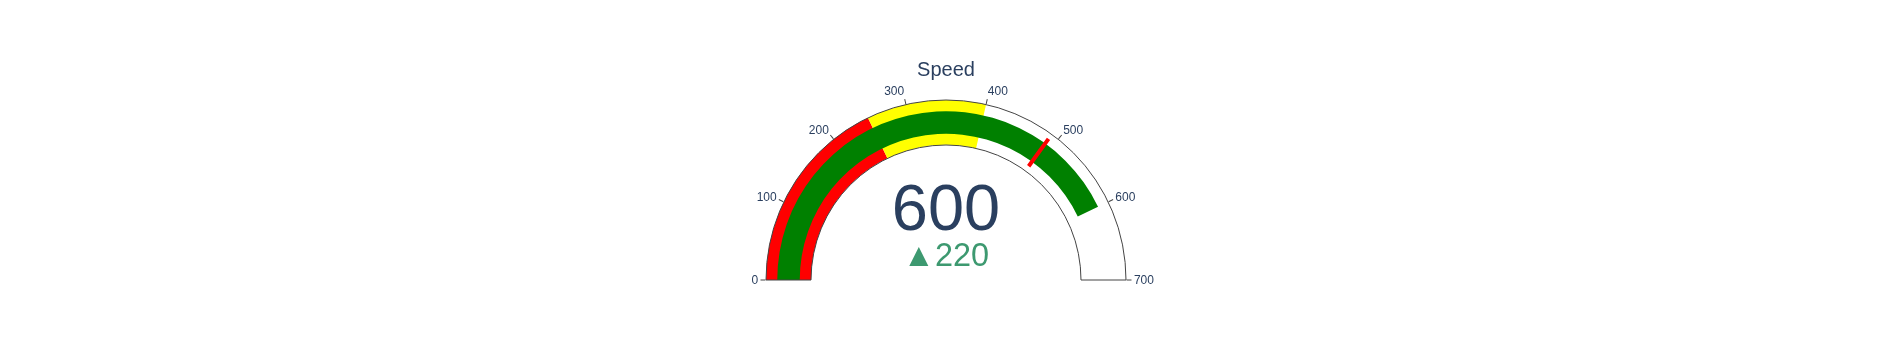

In [25]:
# Gauge plot
fig = go.Figure(go.Indicator(
    domain = {'x': [0, 1], 'y': [0, 1]},
    value = 600,
    mode = "gauge+number+delta",
    title = {'text': "Speed"},
    delta = {'reference': 380},
    gauge = {'axis': {'range': [None, 700]},
             'steps' : [
                 {'range': [0, 250], 'color': "red"},
                 {'range': [250, 400], 'color': "yellow"}],
             'threshold' : {'line': {'color': "red", 'width': 4}, 'thickness': 0.75, 'value': 490}}))

fig.show()

## Others